In [3]:
#!/usr/bin/env python3
"""
Perform EOF analysis on all ensemble members for a chosen CMIP6 model.
Works for annual-mean CMIP6 data with 2D latitude/longitude fields (dims j,i).

Author: Freja Klejnstrup
Date: 2025-10-28
"""

import xarray as xr
import numpy as np
import os
from eofs.xarray import Eof

# -----------------------------
# User settings
# -----------------------------
model = 'EC-Earth3'
base_dir = "/data/projects/nckf/frekle/CMIP6_data"
members = [f"r{i}i1p1f1" for i in range(1, 26)]  # r1–r25
variables = ['thetao', 'so']  # 3D temp and salinity
output_dir = f"/data/projects/nckf/frekle/EOF_results/{model}"
os.makedirs(output_dir, exist_ok=True)


# -----------------------------
# Helper functions
# -----------------------------

def load_surface_data(var, member):
    """Load 3D CMIP6 field and extract the surface layer (lev=0)."""
    file_path = f"{base_dir}/{var}/{var}_masked_{member}.nc"
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing file: {file_path}")

    ds = xr.open_dataset(file_path)

    da = ds[var]
    # Extract surface (first depth level)
    if 'lev' in da.dims:
        da = da.isel(lev=0)

    # Subset time range if needed
    if 'time' in da.dims:
        da = da.sel(time=slice("1840", "2014"))

    # Attach coordinates
    if 'latitude' in ds and 'longitude' in ds:
        da = da.assign_coords(lat=ds['latitude'], lon=ds['longitude'])

    return da


def detrend_mean(da):
    """Remove long-term mean to obtain anomalies."""
    return da - da.mean('time')


def calculate_eof(da, n_modes=10):
    """Perform EOF analysis using eofs.xarray."""
    # Compute weights (area weighting with latitude)
    lat = da.lat
    if lat.ndim == 2:
        # Some CMIP6 models use 2D lat/lon fields
        lat_weights = np.sqrt(np.cos(np.deg2rad(lat)))
    else:
        lat_weights = np.sqrt(np.cos(np.deg2rad(lat)))[:, np.newaxis]

    solver = Eof(da, weights=lat_weights)

    eofs = solver.eofsAsCorrelation(neofs=n_modes)
    pcs = solver.pcs(npcs=n_modes, pcscaling=1)
    varfrac = solver.varianceFraction(neigs=n_modes)
    return eofs, pcs, varfrac


def save_eof_results(member, varname, eofs, pcs, varfrac):
    """Save EOF results to NetCDF file."""
    out = xr.Dataset({
        "EOFs": eofs,
        "PCs": pcs,
        "variance_fraction": varfrac
    })
    outfile = f"{output_dir}/EOF_{varname}_{member}.nc"
    out.to_netcdf(outfile)
    print(f"✅ Saved EOF results for {varname} {member} → {outfile}")


# -----------------------------
# Main loop
# -----------------------------
for member in members:
    print(f"\nProcessing ensemble member: {member}")

    for var in variables:
        try:
            da = load_surface_data(var, member)
            da_anom = detrend_mean(da)
            eofs, pcs, varfrac = calculate_eof(da_anom, n_modes=10)
            save_eof_results(member, var, eofs, pcs, varfrac)

        except Exception as e:
            print(f"⚠️ Skipped {var} {member} due to: {e}")
print("\nAll done!")


Processing ensemble member: r1i1p1f1
⚠️ Skipped thetao r1i1p1f1 due to: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/CMIP6_data/thetao/thetao_masked_r1i1p1f1.nc'
⚠️ Skipped so r1i1p1f1 due to: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/CMIP6_data/so/so_masked_r1i1p1f1.nc'

Processing ensemble member: r2i1p1f1
⚠️ Skipped thetao r2i1p1f1 due to: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/CMIP6_data/thetao/thetao_masked_r2i1p1f1.nc'
⚠️ Skipped so r2i1p1f1 due to: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/CMIP6_data/so/so_masked_r2i1p1f1.nc'

Processing ensemble member: r3i1p1f1
⚠️ Skipped thetao r3i1p1f1 due to: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/CMIP6_data/thetao/thetao_masked_r3i1p1f1.nc'
⚠️ Skipped so r3i1p1f1 due to: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/CMIP6_data/so/so_masked_r3i1p1f1.nc'

Processing ensemble member: r4i1p1f1
⚠️ Skipped thetao r4i1p1f1 due to: [Errno -1

In [4]:
#!/usr/bin/env python3
"""
Compare EOF modes across ensemble members for a given CMIP6 model.

Creates one large figure:
 ├── 3 rows (for 3 selected members)
 └── 4 columns: EOF1 | EOF2 | EOF3 | PCs (PC1–3 time series)

Also includes:
 - PC1 correlation matrix across all members
 - Explained variance summary
 - Decodes time to calendar years
 - Full Atlantic extent & geographic labels

Author: Freja Klejnstrup
Date: 2025-10-29
"""

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cftime

# -----------------------------
# User settings
# -----------------------------
model = "EC-Earth3"
varname = "thetao"  # change to "so" for salinity
base_dir = f"/data/projects/nckf/frekle/EOF_results/{model}"
members = [f"r{i}i1p1f1" for i in range(1, 26)]
plot_members = ["r1i1p1f1", "r6i1p1f1", "r10i1p1f1", "r17i1p1f1"]  # shown in the figure
n_modes = 3

# Output directory
fig_root = "/data/users/frekle/EOF/Figures"
fig_dir = os.path.join(fig_root, varname)
os.makedirs(fig_dir, exist_ok=True)
print(f"📁 Figures will be saved in: {fig_dir}")

# -----------------------------
# Helper functions
# -----------------------------
def load_eof_results(member, var):
    path = f"{base_dir}/EOF_{var}_{member}.nc"
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    return xr.open_dataset(path)


def decode_time_to_years(time):
    if np.issubdtype(time.dtype, np.number) and "units" in time.attrs:
        try:
            tdt = cftime.num2date(time.values, units=time.attrs["units"],
                                  calendar=time.attrs.get("calendar", "gregorian"))
            return np.array([t.year + t.timetuple().tm_yday / 365.25 for t in tdt])
        except Exception:
            return np.arange(len(time))
    else:
        try:
            arr = xr.DataArray(time)
            return (arr.dt.year + arr.dt.dayofyear / 365.25).values
        except Exception:
            return np.arange(len(time))


def correlate_pc_time_series(pc_dict, mode=0):
    names = list(pc_dict.keys())
    n = len(names)
    corr = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            a = pc_dict[names[i]][:, mode]
            b = pc_dict[names[j]][:, mode]
            mask = np.isfinite(a) & np.isfinite(b)
            corr[i, j] = np.corrcoef(a[mask], b[mask])[0, 1]
    return corr, names


# -----------------------------
# Load EOFs, PCs, variance
# -----------------------------
eof_patterns, pcs, varfrac, times = {}, {}, {}, {}

for m in members:
    try:
        ds = load_eof_results(m, varname)
        eof_patterns[m] = ds["EOFs"].isel(mode=slice(0, n_modes))
        pcs[m] = ds["PCs"].values
        varfrac[m] = ds["variance_fraction"].values
        years = decode_time_to_years(ds["PCs"]["time"]) if "time" in ds["PCs"].coords else np.arange(pcs[m].shape[0])
        times[m] = years
    except Exception as e:
        print(f"⚠️ Skipping {m}: {e}")

print(f"✅ Loaded EOF results for {len(eof_patterns)} members.")

# -----------------------------
# -----------------------------
# 1️⃣ Big figure: EOF maps + PC plots (3×4)
# -----------------------------
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(len(plot_members), 4, width_ratios=[1, 1, 1, 1.2])

def draw_map(ax, field, lon, lat, title):
    pcm = ax.pcolormesh(lon, lat, field, transform=ccrs.PlateCarree(),
                        cmap="RdBu_r", shading="auto")
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    ax.set_extent([-100, 20, -60, 80])
    ax.set_xticks(np.arange(-100, 40, 20), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-60, 90, 20), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=8)
    ax.set_xlabel("Longitude (°E)", fontsize=9)
    ax.set_ylabel("Latitude (°N)", fontsize=9)
    ax.set_title(title, fontsize=9)
    return pcm

last_pcm = None
for i, member in enumerate(plot_members):
    if member not in eof_patterns:
        continue
    ds = eof_patterns[member]
    lon, lat = ds["longitude"], ds["latitude"]

    # --- Three Cartopy maps
    for mode in range(3):
        ax_map = fig.add_subplot(gs[i, mode], projection=ccrs.PlateCarree())
        title = f"EOF{mode+1} ({varfrac[member][mode]*100:.1f}%)"
        last_pcm = draw_map(ax_map, ds.isel(mode=mode), lon, lat, title)

    # --- One normal plot for PCs
    ax_pc = fig.add_subplot(gs[i, 3])
    for mode in range(3):
        ax_pc.plot(times[member], pcs[member][:, mode],
                   label=f"PC{mode+1}", lw=1.2)
    ax_pc.set_xlim(times[member][0], times[member][-1])
    ax_pc.set_xticks(np.arange(1850, 2020, 20))
    ax_pc.set_xlabel("Year")
    ax_pc.set_ylabel("Amplitude (a.u.)")
    ax_pc.set_title(f"{member} PCs", fontsize=9)
    ax_pc.grid(True, linestyle="--", alpha=0.4)
    if i == 0:
        ax_pc.legend(fontsize=8, loc="upper right")

# Shared colorbar
cax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(last_pcm, cax=cax, label="EOF amplitude (°C)")

plt.suptitle(f"{model} {varname.upper()} | EOF Modes 1–3 + PCs (4 members)", fontsize=15)
plt.subplots_adjust(wspace=0.3, hspace=0.25, right=0.9, top=0.93, bottom=0.05)
plt.savefig(f"{fig_dir}/EOF_PCs_{varname}_4members_combined.png", dpi=300)
plt.close()
print("✅ Saved combined EOF+PC figure (4×4 grid).")


# -----------------------------
# 2️⃣ PC1 time series (all members + ensemble mean)
# -----------------------------
plt.figure(figsize=(12, 6))

# Collect PC1s into an aligned matrix
pc1_matrix = []
min_len = min(pcs[m].shape[0] for m in pcs.keys())
common_time = None

for member in pcs.keys():
    # Truncate to minimum length for safe averaging
    pc1 = pcs[member][:min_len, 0]
    pc1_matrix.append(pc1)
    if common_time is None:
        common_time = times[member][:min_len]
    plt.plot(times[member][:min_len], pc1, color='gray', alpha=0.4, lw=1)

# Ensemble mean
pc1_mean = np.mean(pc1_matrix, axis=0)
plt.plot(common_time, pc1_mean, color='black', lw=2.5, label='Ensemble mean')

# Plot styling
plt.title(f"{model} {varname.upper()} | PC1 Time Series Across Members")
plt.xlabel("Year")
plt.ylabel("PC1 (a.u.)")
plt.xticks(np.arange(1850, 2020, 20))
plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{fig_dir}/PC1_timeseries_{varname}.png", dpi=300)
plt.close()
print("✅ Saved PC1 time series comparison plot (with ensemble mean).")

# -----------------------------
# 3️⃣ Explained variance (mean ± std)
# -----------------------------
var_table = np.array([varfrac[m][:3] for m in pcs.keys()])
mean_var = var_table.mean(axis=0)
std_var = var_table.std(axis=0)

plt.figure(figsize=(8, 5))
x = np.arange(1, 4)
plt.bar(x, mean_var*100, yerr=std_var*100, capsize=5)
plt.xticks(x, [f"EOF{i}" for i in x])
plt.ylabel("Explained Variance (%)")
plt.title(f"{model} {varname.upper()} | Mean Explained Variance (±1σ)")
plt.tight_layout()
plt.savefig(f"{fig_dir}/explained_variance_{varname}.png", dpi=300)
plt.close()
print("✅ Saved explained variance summary.")






📁 Figures will be saved in: /data/users/frekle/EOF/Figures/thetao
⚠️ Skipping r1i1p1f1: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/EOF_results/EC-Earth3/EOF_thetao_r1i1p1f1.nc'
⚠️ Skipping r2i1p1f1: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/EOF_results/EC-Earth3/EOF_thetao_r2i1p1f1.nc'
⚠️ Skipping r3i1p1f1: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/EOF_results/EC-Earth3/EOF_thetao_r3i1p1f1.nc'
⚠️ Skipping r4i1p1f1: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/EOF_results/EC-Earth3/EOF_thetao_r4i1p1f1.nc'
⚠️ Skipping r5i1p1f1: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/EOF_results/EC-Earth3/EOF_thetao_r5i1p1f1.nc'
⚠️ Skipping r6i1p1f1: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/EOF_results/EC-Earth3/EOF_thetao_r6i1p1f1.nc'
⚠️ Skipping r7i1p1f1: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/EOF_results/EC-Earth3/EOF_thetao_r7i1p1f1.nc'
⚠️ Skipping r8i1p1f1: [Errno -101] Net

ValueError: min() arg is an empty sequence

<Figure size 1200x600 with 0 Axes>

### spatial correlation between each of its EOF

🌊 Found 1 AMOC files
✅ Computed ensemble mean and std of AMOC streamfunction


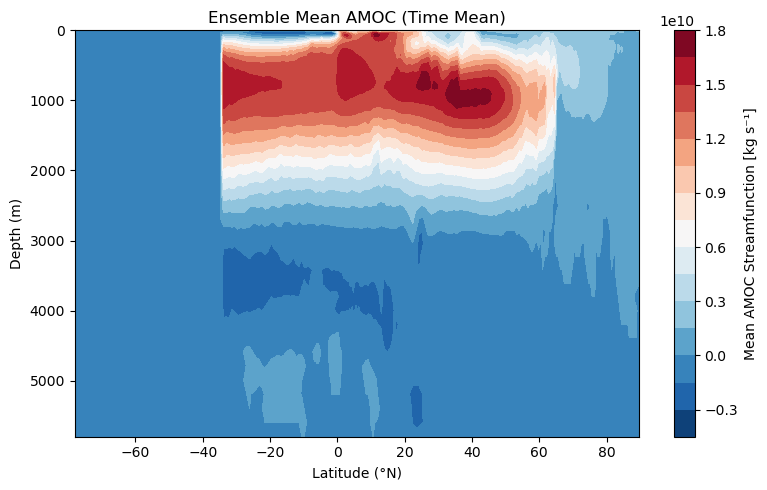

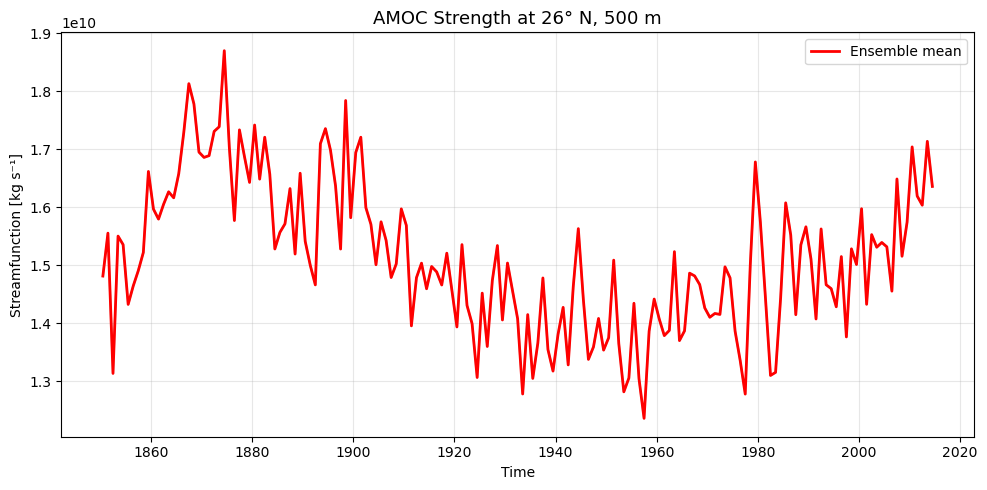

🎯 Plotted AMOC mean structure and strength at 26° N, 500 m


In [3]:
import xarray as xr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# =====================================================
# Helper: spatial correlation between two EOF patterns
# =====================================================
def pattern_corr(eof1, eof2):
    """Compute spatial correlation between two EOFs."""
    a = eof1.values.flatten()
    b = eof2.values.flatten()
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    if len(a) < 3:
        return np.nan
    return np.corrcoef(a, b)[0, 1]


# =====================================================
# Main alignment function
# =====================================================
def align_eofs_from_files(
    data_dir,
    varname="thetao",
    ref_member="r1i1p1f1",
    plot_corr=True,
    save_aligned=True,
    n_modes_to_plot=None
):
    """
    Align EOF signs and order across ensemble members.
    Displays correlation matrices and saves aligned files
    in a dedicated 'aligned/' folder.
    
    Parameters
    ----------
    data_dir : str
        Directory containing EOF result files.
    varname : str
        Variable name (used in filenames, e.g. 'thetao').
    ref_member : str
        Reference ensemble member (e.g. 'r1i1p1f1').
    plot_corr : bool
        Whether to display correlation matrices.
    save_aligned : bool
        Whether to save aligned EOF/PC files.
        
    Returns
    -------
    aligned_eofs : dict[str, xr.DataArray]
    aligned_pcs : dict[str, xr.DataArray]
    """
    # -------------------------------------------------
    # Find EOF files
    # -------------------------------------------------
    file_pattern = os.path.join(data_dir, f"EOF_{varname}_r*.nc")
    files = sorted(glob.glob(file_pattern))
    if not files:
        raise FileNotFoundError(f"No files found in {data_dir} matching pattern 'EOF_{varname}_r*.nc'")
    
    print(f"📂 Found {len(files)} EOF files:")
    for f in files:
        print("   ", os.path.basename(f))
    
    # -------------------------------------------------
    # Load datasets
    # -------------------------------------------------
    eofs_dict, pcs_dict = {}, {}
    for f in files:
        member = os.path.basename(f).split("_")[-1].replace(".nc", "")
        ds = xr.open_dataset(f)
        eofs_dict[member] = ds["EOFs"]
        pcs_dict[member] = ds["PCs"]

    ref_eofs = eofs_dict[ref_member]
    n_modes = ref_eofs.sizes["mode"]
    
    aligned_eofs, aligned_pcs = {}, {}
    
    # -------------------------------------------------
    # Prepare save directory
    # -------------------------------------------------
    if save_aligned:
        aligned_dir = os.path.join(data_dir, "aligned")
        os.makedirs(aligned_dir, exist_ok=True)
        print(f"📁 Aligned files will be saved to: {aligned_dir}\n")
    
    # -------------------------------------------------
    # Loop through members
    # -------------------------------------------------
    for member, eofs in eofs_dict.items():
        pcs = pcs_dict[member].copy()
        
        if member == ref_member:
            aligned_eofs[member] = eofs
            aligned_pcs[member] = pcs
            continue
        
        # Compute correlation matrix
        corr_matrix = np.zeros((n_modes, n_modes))
        for i in range(n_modes):
            for j in range(n_modes):
                corr_matrix[i, j] = pattern_corr(ref_eofs.isel(mode=i), eofs.isel(mode=j))
        
        # Determine best match
        best_match = np.argmax(np.abs(corr_matrix), axis=0)
        
        # Reorder + sign flip
        reordered_eofs = eofs.isel(mode=best_match)
        reordered_pcs = pcs[:, best_match]
        for m in range(n_modes):
            corr = corr_matrix[m, best_match[m]]
            if corr < 0:
                reordered_eofs[m] *= -1
                reordered_pcs[:, m] *= -1
        
        aligned_eofs[member] = reordered_eofs
        aligned_pcs[member] = reordered_pcs
        
        print(f"✅ Aligned {member}: reordered as {best_match + 1}, sign-corrected where needed.")
        
        # -------------------------------------------------
        # Show correlation matrix (no saving)
        if plot_corr:
            # Limit the number of modes to plot
            nm = n_modes_to_plot or n_modes  # use full if not specified
            corr_plot = corr_matrix[:nm, :nm]

            fig, ax = plt.subplots(figsize=(5.5, 4.5))
            im = ax.imshow(corr_plot, cmap="RdBu_r", vmin=-1, vmax=1)
            plt.colorbar(im, ax=ax, label="Correlation coefficient")
            ax.set_title(f"{member} vs {ref_member}\nEOF correlation matrix", fontsize=12)
            ax.set_xlabel(f"{member} EOF modes")
            ax.set_ylabel(f"Reference ({ref_member}) EOF modes")
            ax.set_xticks(range(nm))
            ax.set_xticklabels(range(1, nm + 1))
            ax.set_yticks(range(nm))
            ax.set_yticklabels(range(1, nm + 1))
            plt.tight_layout()
            # plt.show()
        
        # -------------------------------------------------
        # Save aligned files in new folder
        # -------------------------------------------------
        if save_aligned:
            out_path = os.path.join(aligned_dir, f"EOF_{varname}_{member}_aligned.nc")
            xr.Dataset({"EOFs": reordered_eofs, "PCs": reordered_pcs}).to_netcdf(out_path)
            print(f"💾 Saved aligned file: {out_path}\n")
    
    print("🎯 All EOF modes are now aligned and saved.")
    return aligned_eofs, aligned_pcs


# ------------------------------------------------------------
# 6. Load AMOC streamfunction files
# ------------------------------------------------------------
amoc_dir = "/data/projects/nckf/frekle/CMIP6_data/msftyz"
files_amoc = sorted(glob.glob(os.path.join(amoc_dir, "msftyz_Oyear_EC-Earth3_historical_r*i1p1f1_gn_185001-201412_Atl.nc")))
print(f"🌊 Found {len(files_amoc)} AMOC files")

amoc_dict = {}
for f in files_amoc:
    member = os.path.basename(f).split("_")[4]  # extract r1i1p1f1
    ds = xr.open_dataset(f)
    amoc_dict[member] = ds["msftyz"]

# ------------------------------------------------------------
# 7. Compute ensemble mean AMOC field
# ------------------------------------------------------------
all_amoc = xr.concat([amoc_dict[m] for m in amoc_dict], dim="member")
all_amoc["member"] = list(amoc_dict.keys())

amoc_mean = all_amoc.mean(dim="member")
amoc_std  = all_amoc.std(dim="member")

print("✅ Computed ensemble mean and std of AMOC streamfunction")

# ------------------------------------------------------------
# 8. Plot ensemble mean AMOC streamfunction (latitude–depth)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.contourf(
    amoc_mean["rlat"], amoc_mean["lev"], amoc_mean.mean(dim="time"),
    levels=20, cmap="RdBu_r"
)
ax.invert_yaxis()
ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("Depth (m)")
plt.colorbar(im, ax=ax, label="Mean AMOC Streamfunction [kg s⁻¹]")
ax.set_title("Ensemble Mean AMOC (Time Mean)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Plot AMOC strength evolution at chosen lat/depth
# ------------------------------------------------------------
lat_sel = 26   # degrees North
depth_sel = 500  # meters

# Find closest grid points
lat_idx = np.abs(amoc_mean["rlat"] - lat_sel).argmin()
lev_idx = np.abs(amoc_mean["lev"] - depth_sel).argmin()

# Extract time series for each member
amoc_strength = []
for m, da in amoc_dict.items():
    series = da.isel(rlat=lat_idx, lev=lev_idx)
    amoc_strength.append(series)
amoc_strength = xr.concat(amoc_strength, dim="member")
amoc_strength["member"] = list(amoc_dict.keys())

amoc_mean_strength = amoc_strength.mean(dim="member")

# Plot spaghetti + mean
fig, ax = plt.subplots(figsize=(10, 5))
for m in amoc_dict.keys():
    ax.plot(amoc_strength["time"], amoc_strength.sel(member=m), color="gray", alpha=0.5)

ax.plot(amoc_mean_strength["time"], amoc_mean_strength, color="red", lw=2, label="Ensemble mean")
ax.set_title(f"AMOC Strength at {lat_sel}° N, {depth_sel} m", fontsize=13)
ax.set_xlabel("Time")
ax.set_ylabel("Streamfunction [kg s⁻¹]")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"🎯 Plotted AMOC mean structure and strength at {lat_sel}° N, {depth_sel} m")




Found 22 files:
   EOF_thetao_r10i1p1f1.nc
   EOF_thetao_r11i1p1f1.nc
   EOF_thetao_r12i1p1f1.nc
   EOF_thetao_r13i1p1f1.nc
   EOF_thetao_r14i1p1f1.nc
   EOF_thetao_r15i1p1f1.nc
   EOF_thetao_r16i1p1f1.nc
   EOF_thetao_r17i1p1f1.nc
   EOF_thetao_r18i1p1f1.nc
   EOF_thetao_r19i1p1f1.nc
   EOF_thetao_r1i1p1f1.nc
   EOF_thetao_r20i1p1f1.nc
   EOF_thetao_r21i1p1f1.nc
   EOF_thetao_r24i1p1f1.nc
   EOF_thetao_r2i1p1f1.nc
   EOF_thetao_r3i1p1f1.nc
   EOF_thetao_r4i1p1f1.nc
   EOF_thetao_r5i1p1f1.nc
   EOF_thetao_r6i1p1f1.nc
   EOF_thetao_r7i1p1f1.nc
   EOF_thetao_r8i1p1f1.nc
   EOF_thetao_r9i1p1f1.nc

Members: ['r10i1p1f1', 'r11i1p1f1', 'r12i1p1f1', 'r13i1p1f1', 'r14i1p1f1', 'r15i1p1f1', 'r16i1p1f1', 'r17i1p1f1', 'r18i1p1f1', 'r19i1p1f1', 'r1i1p1f1', 'r20i1p1f1', 'r21i1p1f1', 'r24i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1', 'r6i1p1f1', 'r7i1p1f1', 'r8i1p1f1', 'r9i1p1f1']

🔍 Using reference = r10i1p1f1

🔍 Using reference = r11i1p1f1

🔍 Using reference = r12i1p1f1

🔍 Using reference

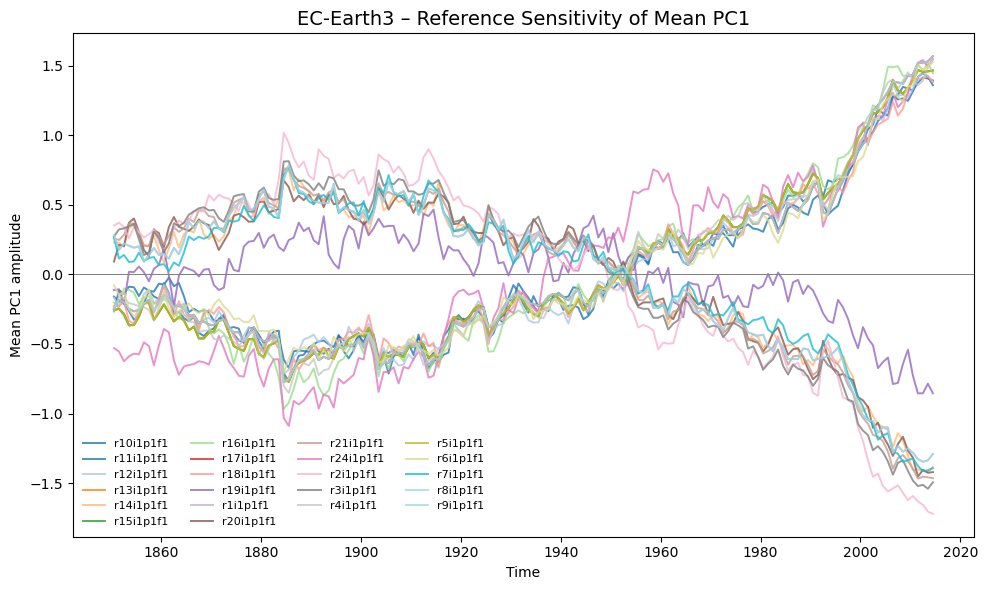

In [9]:
import xarray as xr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# =====================================================
# Helper: spatial correlation between two EOF patterns
# =====================================================
def pattern_corr(eof1, eof2):
    """Compute spatial correlation between two EOFs."""
    a = eof1.values.flatten()
    b = eof2.values.flatten()
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    if len(a) < 3:
        return np.nan
    return np.corrcoef(a, b)[0, 1]


# =====================================================
# LOAD EC-EARTH3 EOF FILES
# =====================================================
DATA_DIR = "/data/projects/nckf/frekle/EOF_results/EC-Earth3/"

files = sorted(glob.glob(os.path.join(DATA_DIR, "EOF_thetao_r*.nc")))
if not files:
    raise FileNotFoundError("No EC-Earth3 EOF files found!")

print(f"Found {len(files)} files:")
for f in files:
    print("  ", os.path.basename(f))

members = []
eofs_all = {}
pcs_all = {}

for f in files:
    name = os.path.basename(f)
    member = name.split("EOF_thetao_")[1].replace(".nc", "")
    ds = xr.open_dataset(f)
    eofs_all[member] = ds["EOFs"]
    pcs_all[member]  = ds["PCs"]
    members.append(member)

members = sorted(members)
print("\nMembers:", members)

n_modes = eofs_all[members[0]].sizes["mode"]
topmode = 1   # we only care about PC1 here


# =====================================================
# MAIN LOOP OVER REFERENCE MEMBERS
# =====================================================
mean_pc1_per_reference = {}

for ref in members:
    print(f"\n🔍 Using reference = {ref}")
    ref_eofs = eofs_all[ref]

    aligned_pc1s = []

    for mem in members:
        eofs_mem = eofs_all[mem]
        pcs_mem  = pcs_all[mem]

        if mem == ref:
            # reference PC1 goes directly
            aligned_pc1s.append(pcs_mem.isel(mode=0))
            continue

        # --- Compute correlation matrix ---
        corr = np.zeros((n_modes, n_modes))
        for i in range(n_modes):
            for j in range(n_modes):
                corr[i, j] = pattern_corr(
                    ref_eofs.isel(mode=i), 
                    eofs_mem.isel(mode=j)
                )

        # --- Determine best matches (note: correct axis = 0) ---
        best_match = np.argmax(np.abs(corr), axis=0)

        # --- Reorder and sign flip PCs ---
        pcs_reordered = pcs_mem[:, best_match]

        for m in range(n_modes):
            if corr[m, best_match[m]] < 0:
                pcs_reordered[:, m] *= -1

        aligned_pc1s.append(pcs_reordered[:, 0])

    # Stack all PC1(t) aligned to this reference
    stack = xr.concat(aligned_pc1s, dim="member")
    mean_pc1 = stack.mean("member")

    mean_pc1_per_reference[ref] = mean_pc1


# =====================================================
# PLOT ALL MEAN PC1 CURVES (REFERENCE SENSITIVITY)
# =====================================================
plt.figure(figsize=(10,6))
colors = plt.cm.tab20(np.linspace(0,1,len(members)))

for i, ref in enumerate(members):
    mean_pc1 = mean_pc1_per_reference[ref]
    plt.plot(mean_pc1["time"], mean_pc1, 
             lw=1.4, alpha=0.8, color=colors[i],
             label=f"{ref}")

plt.axhline(0, color="gray", lw=0.7)
plt.title("EC-Earth3 – Reference Sensitivity of Mean PC1", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Mean PC1 amplitude")
plt.legend(ncol=4, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


Loaded EC-Earth3 members: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 24]


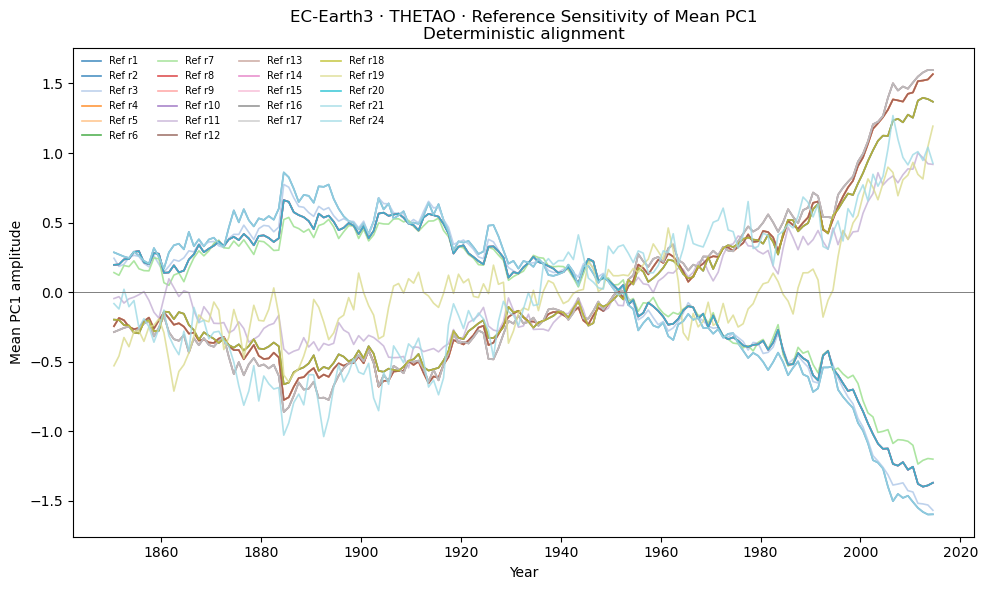

In [1]:
#!/usr/bin/env python3
# =====================================================
# EC-Earth3 — Reference Sensitivity of EOF Alignment
# Deterministic (CESM-style) alignment across references
# Freja Klejnstrup · DMI/AU · 2025
# =====================================================

import xarray as xr
import numpy as np
import glob
import re
import os
import matplotlib.pyplot as plt

# ================================
# CONFIG
# ================================
MODEL = "EC-Earth3"
VAR   = "thetao"

IN_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/"

TOP_MODES = 3      # Only align EOF1-EOF3, but correlation uses ALL modes


# ================================
# Helper: spatial correlation
# ================================
def pattern_corr(eof1, eof2):
    """Compute spatial (Pearson) correlation between two 2D EOF patterns."""
    a = eof1.values.flatten()
    b = eof2.values.flatten()

    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan

    a = a[m] - a[m].mean()
    b = b[m] - b[m].mean()

    return float(np.dot(a, b) /
                 (np.sqrt((a*a).sum()) * np.sqrt((b*b).sum())))


# ================================
# Deterministic alignment
# ================================
def deterministic_align(ref_eofs, mem_eofs, topmodes=TOP_MODES):
    """
    Deterministic mode alignment:
      • Build full correlation matrix
      • For each mode i → choose j = argmax(|corr[i,j]|)
      • Apply sign so corr > 0
      • No 'used' filtering → deterministic & stable
    """

    nm = ref_eofs.sizes["mode"]
    corr_mat = np.zeros((topmodes, nm))

    # --- compute full correlation matrix ---
    for i in range(topmodes):
        for j in range(nm):
            corr_mat[i, j] = pattern_corr(ref_eofs.isel(mode=i),
                                          mem_eofs.isel(mode=j))

    # --- strict row-based matching ---
    mapping = {i: int(np.nanargmax(np.abs(corr_mat[i, :])))
               for i in range(topmodes)}

    # --- sign correction ---
    aligned = []
    for i in range(topmodes):
        j = mapping[i]
        corr = corr_mat[i, j]
        sign = 1 if corr >= 0 else -1
        aligned.append(mem_eofs.isel(mode=j) * sign)

    aligned = xr.concat(aligned, dim="mode")
    aligned = aligned.assign_coords(mode=np.arange(1, topmodes + 1))

    return aligned, mapping


# ================================
# Load all raw EOF/PC files
# ================================
files = sorted(glob.glob(os.path.join(IN_DIR,
                                      f"EOF_{VAR}_r*i1p1f1.nc")))

if not files:
    raise FileNotFoundError("No raw EOF files found!")

members = []
eofs_all = {}
pcs_all = {}

for f in files:
    fname = os.path.basename(f)
    m = re.search(r"_r(\d+)i1p1f1", fname)
    if not m:
        continue

    member = int(m.group(1))
    ds = xr.open_dataset(f)

    eofs_all[member] = ds["EOFs"]     # all modes kept
    pcs_all[member]  = ds["PCs"]      # all modes kept

    members.append(member)

members = sorted(members)
print(f"Loaded EC-Earth3 members: {members}")


# ================================
# Reference-sensitivity analysis
# ================================
plt.figure(figsize=(10, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(members)))

for idx, ref in enumerate(members):
    ref_eofs = eofs_all[ref]

    aligned_pc1_list = []

    # --- align ALL members to this reference ---
    for mem in members:
        mem_eofs = eofs_all[mem]
        mem_pcs  = pcs_all[mem]

        if mem == ref:
            # reference → PC1 is just its own PC1
            aligned_pc1 = mem_pcs.isel(mode=0)

        else:
            # deterministic alignment
            aligned_eofs, mapping = deterministic_align(ref_eofs, mem_eofs,
                                                         TOP_MODES)

            # reorder + sign-correct PC1
            j = mapping[0]
            corr = pattern_corr(ref_eofs.isel(mode=0),
                                mem_eofs.isel(mode=j))
            sign = 1 if corr >= 0 else -1

            aligned_pc1 = mem_pcs.isel(mode=j) * sign

        aligned_pc1_list.append(aligned_pc1)

    # mean across members
    stack = xr.concat(aligned_pc1_list, dim="member")
    pc1_mean = stack.mean("member")

    plt.plot(pc1_mean["time"], pc1_mean,
             lw=1.2, alpha=0.8, color=colors[idx],
             label=f"Ref r{ref}")

plt.axhline(0, color="gray", lw=0.7)
plt.title(f"{MODEL} · {VAR.upper()} · Reference Sensitivity of Mean PC1\nDeterministic alignment")
plt.xlabel("Year")
plt.ylabel("Mean PC1 amplitude")
plt.legend(ncol=4, fontsize=7, frameon=False)
plt.tight_layout()
plt.show()


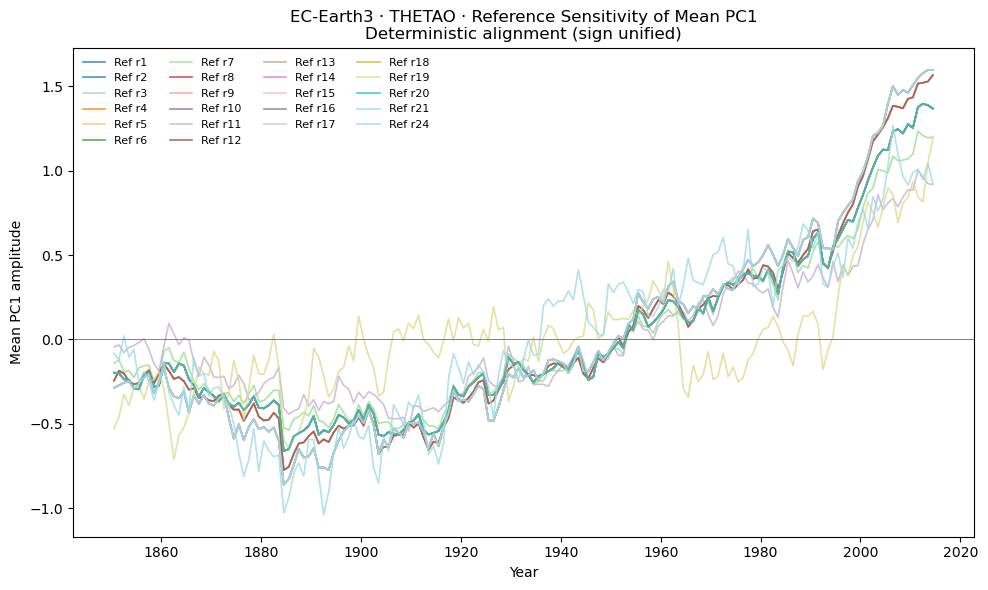

In [4]:
# ================================
# Reference-sensitivity analysis
# ================================
plt.figure(figsize=(10, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(members)))

reference_1 = members[0]   # assume r1 is the first listed
ref1_pc1_mean = None       # will store the mean PC1 for ref = r1

all_pc1_means = []         # store for global sign checks if needed

for idx, ref in enumerate(members):
    ref_eofs = eofs_all[ref]

    aligned_pc1_list = []

    for mem in members:
        mem_eofs = eofs_all[mem]
        mem_pcs  = pcs_all[mem]

        if mem == ref:
            aligned_pc1 = mem_pcs.isel(mode=0)
        else:
            aligned_eofs, mapping = deterministic_align(ref_eofs, mem_eofs, TOP_MODES)
            j = mapping[0]
            corr = pattern_corr(ref_eofs.isel(mode=0), mem_eofs.isel(mode=j))
            sign = 1 if corr >= 0 else -1
            aligned_pc1 = mem_pcs.isel(mode=j) * sign

        aligned_pc1_list.append(aligned_pc1)

    stack = xr.concat(aligned_pc1_list, dim="member")
    pc1_mean = stack.mean("member")

    # -------------------------------------
    # 🔥 NEW: enforce globally consistent sign
    # -------------------------------------
    if ref == reference_1:
        # store sign reference
        ref1_pc1_mean = pc1_mean
    else:
        corr_to_ref1 = np.corrcoef(
            pc1_mean.values,
            ref1_pc1_mean.values
        )[0, 1]

        if corr_to_ref1 < 0:
            pc1_mean = pc1_mean * -1

    # ---------------------------------------------------
    # 🔥 EXTRA: enforce temporal direction (negative → positive)
    # ---------------------------------------------------
    # Compute linear trend sign
    t_numeric = np.arange(pc1_mean.size)
    coef = np.polyfit(t_numeric, pc1_mean.values, 1)[0]  # slope

    # If slope is negative → flip
    if coef < 0:
        pc1_mean = pc1_mean * -1


        all_pc1_means.append(pc1_mean)

    # plot line
    plt.plot(pc1_mean["time"], pc1_mean,
             lw=1.2, alpha=0.8, color=colors[idx],
             label=f"Ref r{ref}")

plt.axhline(0, color="gray", lw=0.7)
plt.title(f"{MODEL} · {VAR.upper()} · Reference Sensitivity of Mean PC1\nDeterministic alignment (sign unified)")
plt.xlabel("Year")
plt.ylabel("Mean PC1 amplitude")
plt.legend(ncol=4, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()



Searching: /data/projects/nckf/frekle/EOF_results/EC-Earth3/aligned/EOF_thetao_r3i1p1f1_aligned.nc
✅ Loaded PCs from 1 members.


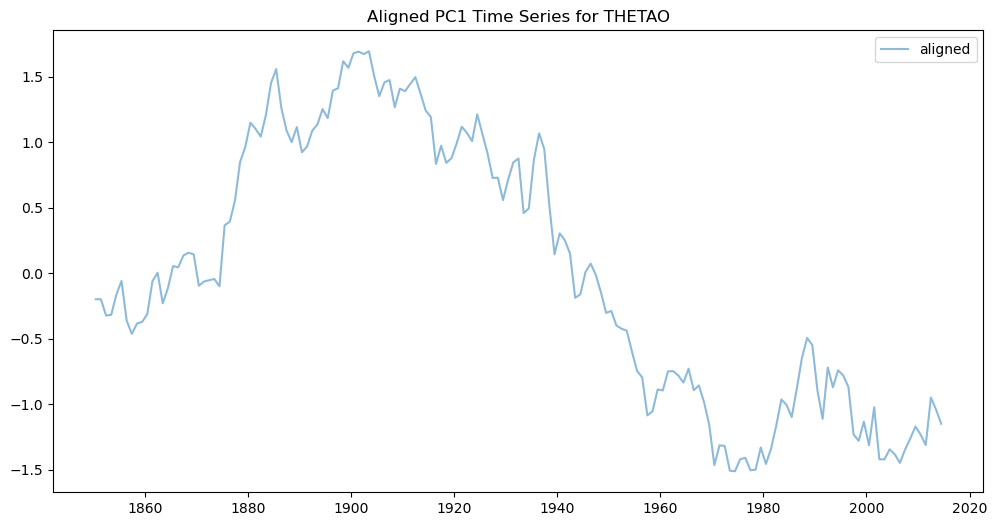

In [4]:
# plot aligned PC's time series
import xarray as xr
import glob
import os
import matplotlib.pyplot as plt

# --- load aligned files ---
folder = "/data/projects/nckf/frekle/EOF_results/EC-Earth3/aligned"
VAR = "thetao"
aligned = True  # load aligned files
pattern = os.path.join(folder, f"EOF_{VAR}_r3i1p1f1_aligned.nc")  # raw files
files = sorted(glob.glob(pattern))
print(f"\nSearching: {pattern}")

# --- collect PCs ---
pcs_dict = {}
for f in files:
    member = os.path.basename(f).split("_")[-1].replace(".nc", "")
    ds = xr.open_dataset(f)
    pcs_dict[member] = ds["PCs"]
print(f"✅ Loaded PCs from {len(pcs_dict)} members.")

# --- plot PC1 time series ---
plt.figure(figsize=(12, 6))
for member, pcs in pcs_dict.items():
    plt.plot(pcs["time"], pcs[:, 0], label=member, alpha=0.5)
plt.title(f"Aligned PC1 Time Series for {VAR.upper()}")
plt.legend()
plt.show()  

📂 Found 22 EOF files:
    EOF_thetao_r10i1p1f1.nc
    EOF_thetao_r11i1p1f1.nc
    EOF_thetao_r12i1p1f1.nc
    EOF_thetao_r13i1p1f1.nc
    EOF_thetao_r14i1p1f1.nc
    EOF_thetao_r15i1p1f1.nc
    EOF_thetao_r16i1p1f1.nc
    EOF_thetao_r17i1p1f1.nc
    EOF_thetao_r18i1p1f1.nc
    EOF_thetao_r19i1p1f1.nc
    EOF_thetao_r1i1p1f1.nc
    EOF_thetao_r20i1p1f1.nc
    EOF_thetao_r21i1p1f1.nc
    EOF_thetao_r24i1p1f1.nc
    EOF_thetao_r2i1p1f1.nc
    EOF_thetao_r3i1p1f1.nc
    EOF_thetao_r4i1p1f1.nc
    EOF_thetao_r5i1p1f1.nc
    EOF_thetao_r6i1p1f1.nc
    EOF_thetao_r7i1p1f1.nc
    EOF_thetao_r8i1p1f1.nc
    EOF_thetao_r9i1p1f1.nc
📁 Aligned files will be saved to: /data/projects/nckf/frekle/EOF_results/EC-Earth3/aligned

✅ Aligned r10i1p1f1: reordered as [1 2 5 4 5 6 8 9 8 8], sign-corrected where needed.


PermissionError: [Errno 13] Permission denied: '/data/projects/nckf/frekle/EOF_results/EC-Earth3/aligned/EOF_thetao_r10i1p1f1_aligned.nc'

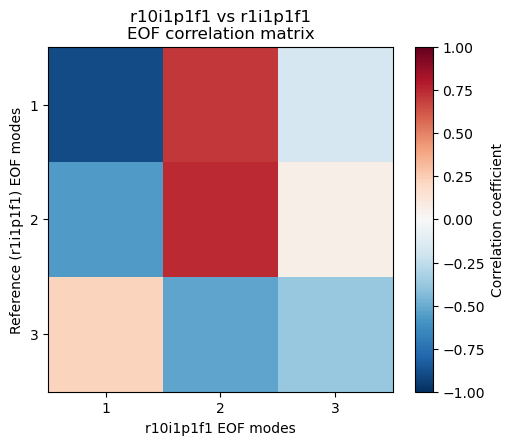

In [ ]:
aligned_eofs, aligned_pcs = align_eofs_from_files(
    data_dir="/data/projects/nckf/frekle/EOF_results/EC-Earth3",
    varname="thetao",
    ref_member="r1i1p1f1",
    plot_corr=True,
    save_aligned=True,
    n_modes_to_plot=3  # 👈 Only show first 3 EOF modes in the plot
)




In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

def analyze_eof_alignment(aligned_eofs, ref_member='r1i1p1f1', n_modes=3, plot=True):
    """
    Diagnose EOF alignment across ensemble members.
    Prints which modes were swapped or sign-flipped
    and optionally plots correlation matrices.
    """
    ref_eofs = aligned_eofs[ref_member]
    members = list(aligned_eofs.keys())

    print(f"\n🔍 EOF Alignment Diagnostics (reference = {ref_member})")
    print("------------------------------------------------------------")

    for member in members:
        if member == ref_member:
            continue

        eofs = aligned_eofs[member]
        corr_matrix = np.zeros((n_modes, n_modes))
        for i in range(n_modes):
            for j in range(n_modes):
                a = ref_eofs.isel(mode=i).values.flatten()
                b = eofs.isel(mode=j).values.flatten()
                mask = np.isfinite(a) & np.isfinite(b)
                if mask.sum() < 3:
                    corr_matrix[i, j] = np.nan
                else:
                    corr_matrix[i, j] = np.corrcoef(a[mask], b[mask])[0, 1]

        # Find best matches
        best_match = np.argmax(np.abs(corr_matrix), axis=0)

        # Detect swaps and sign flips
        swaps, sign_flips = [], []
        for j in range(n_modes):
            i = best_match[j]
            r = corr_matrix[i, j]
            if i != j:
                swaps.append(f"{j+1}↔{i+1}")
            if r < 0:
                sign_flips.append(f"{j+1}")

        # ---- Text summary ----
        mapping = ", ".join([f"{j+1}→{best_match[j]+1}" for j in range(n_modes)])
        print(f"🧩 {member}: Mode mapping [{mapping}]")
        if swaps:
            print(f"   🔄 Swapped modes: {', '.join(swaps)}")
        if sign_flips:
            print(f"   🔃 Sign flipped: EOF {', '.join(sign_flips)}")
        if not swaps and not sign_flips:
            print("   ✅ Perfect alignment with reference")
        print("------------------------------------------------------------")


# Example call (after running your alignment)
analyze_eof_alignment(aligned_eofs, ref_member='r1i1p1f1', n_modes=5, plot=True)


### Atlantic mask

In [ ]:
import os
import glob
import xarray as xr

# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------
SRC_BASE = "/dmidata/projects/nckf/cmip6/historical/EC-Earth3"
DEST_BASE = "/data/projects/nckf/frekle/CMIP6_data/msftyz/Atl"

# Create output folder if it doesn't exist
os.makedirs(DEST_BASE, exist_ok=True)

print("🌊 Extracting Atlantic basin (basin=1) from EC-Earth3 AMOC files...")
print(f"Saving to: {DEST_BASE}\n")

# ---------------------------------------------------------------
# Loop through all ensemble members
# ---------------------------------------------------------------
members = sorted(glob.glob(os.path.join(SRC_BASE, "r*i1p1f1")))

for member_path in members:
    member = os.path.basename(member_path)
    src_file = os.path.join(
        member_path,
        "Oyear",
        "msftyz",
        f"msftyz_Oyear_EC-Earth3_historical_{member}_gn_185001-201412.nc"
    )
    dest_file = os.path.join(
        DEST_BASE,
        f"msftyz_Oyear_EC-Earth3_historical_{member}_gn_185001-201412_Atl.nc"
    )

    if not os.path.exists(src_file):
        print(f"⚠️  Missing file for {member}, skipped.")
        continue

    try:
        ds = xr.open_dataset(src_file)

        if "basin" in ds.dims:
            # Select basin index 1 (Atlantic)
            da = ds["msftyz"].isel(basin=1)
        else:
            print(f"⚠️  No 'basin' dimension in {member}, copying as-is.")
            da = ds["msftyz"]

        # Drop basin coordinate and save
        da.to_netcdf(dest_file)
        print(f"✅ Saved Atlantic-only file for {member}:")
        print(f"   {dest_file}\n")

        ds.close()

    except Exception as e:
        print(f"❌ Error processing {member}: {e}\n")

print("🎯 Done! All Atlantic files saved in:")
print(f"   {DEST_BASE}")


🌊 Extracting Atlantic basin (basin=1) from EC-Earth3 AMOC files...
Saving to: /data/projects/nckf/frekle/CMIP6_data/msftyz/Atl

✅ Saved Atlantic-only file for r10i1p1f1:
   /data/projects/nckf/frekle/CMIP6_data/msftyz/Atl/msftyz_Oyear_EC-Earth3_historical_r10i1p1f1_gn_185001-201412_Atl.nc

✅ Saved Atlantic-only file for r11i1p1f1:
   /data/projects/nckf/frekle/CMIP6_data/msftyz/Atl/msftyz_Oyear_EC-Earth3_historical_r11i1p1f1_gn_185001-201412_Atl.nc

✅ Saved Atlantic-only file for r12i1p1f1:
   /data/projects/nckf/frekle/CMIP6_data/msftyz/Atl/msftyz_Oyear_EC-Earth3_historical_r12i1p1f1_gn_185001-201412_Atl.nc

✅ Saved Atlantic-only file for r13i1p1f1:
   /data/projects/nckf/frekle/CMIP6_data/msftyz/Atl/msftyz_Oyear_EC-Earth3_historical_r13i1p1f1_gn_185001-201412_Atl.nc

✅ Saved Atlantic-only file for r14i1p1f1:
   /data/projects/nckf/frekle/CMIP6_data/msftyz/Atl/msftyz_Oyear_EC-Earth3_historical_r14i1p1f1_gn_185001-201412_Atl.nc

✅ Saved Atlantic-only file for r15i1p1f1:
   /data/projec

Found 22 EOF files.


Running alignment for each reference: 100%|██████████| 22/22 [00:55<00:00,  2.51s/it]


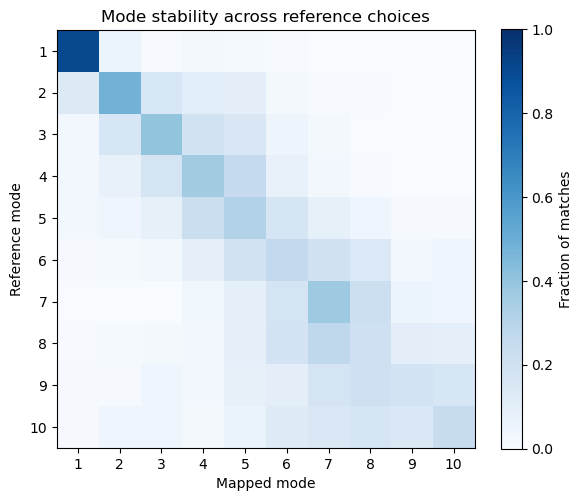

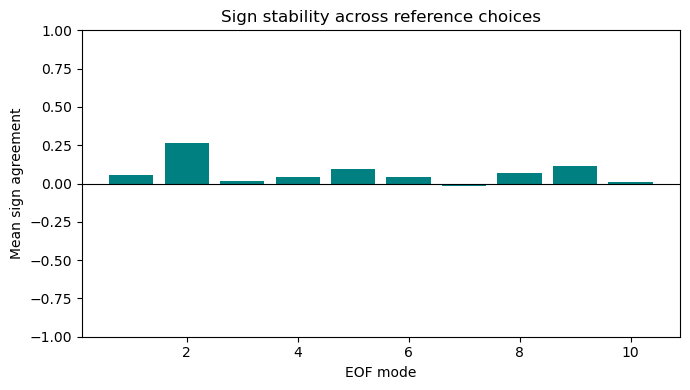

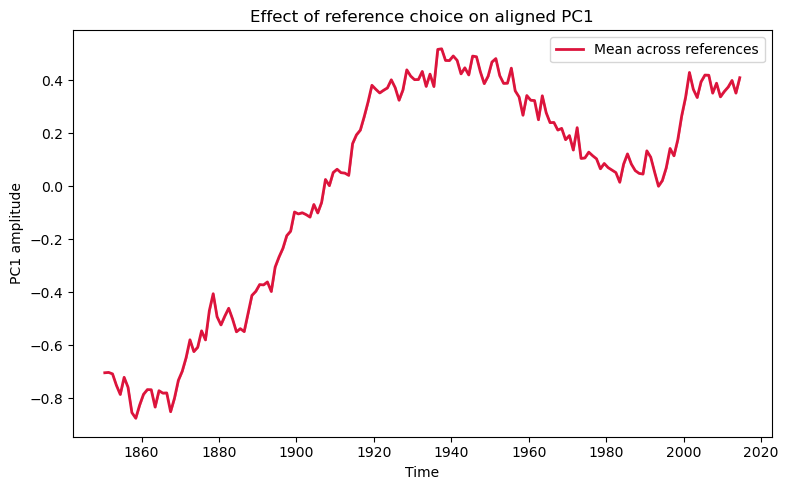

In [15]:
import xarray as xr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# =====================================================
# Helper: spatial correlation between two EOF patterns
# =====================================================
def pattern_corr(eof1, eof2):
    """Compute spatial correlation between two EOFs."""
    a, b = eof1.values.flatten(), eof2.values.flatten()
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    if len(a) < 3:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

# =====================================================
# Load all EOF files
# =====================================================
data_dir = "/data/projects/nckf/frekle/EOF_results/EC-Earth3/"
varname = "thetao"

files = sorted(glob.glob(os.path.join(data_dir, f"EOF_{varname}_r*.nc")))
members = [os.path.basename(f).split("_")[-1].replace(".nc", "") for f in files]
n_members = len(members)

print(f"Found {n_members} EOF files.")

# Load all EOFs & PCs into dictionaries
eofs_dict, pcs_dict = {}, {}
for f in files:
    member = os.path.basename(f).split("_")[-1].replace(".nc", "")
    ds = xr.open_dataset(f)
    eofs_dict[member] = ds["EOFs"]
    pcs_dict[member] = ds["PCs"]

n_modes = eofs_dict[members[0]].sizes["mode"]

# Arrays to store alignment info
corr_all = np.zeros((n_members, n_members, n_modes, n_modes))
sign_all = np.zeros((n_members, n_members, n_modes))
mapping_all = np.zeros((n_members, n_members, n_modes), dtype=int)

# =====================================================
# Perform alignment using each member as reference
# =====================================================
for i_ref, ref_member in enumerate(tqdm(members, desc="Running alignment for each reference")):
    ref_eofs = eofs_dict[ref_member]
    
    for i_target, target_member in enumerate(members):
        eofs = eofs_dict[target_member]
        
        # Compute correlation matrix
        corr_matrix = np.zeros((n_modes, n_modes))
        for i in range(n_modes):
            for j in range(n_modes):
                corr_matrix[i, j] = pattern_corr(ref_eofs.isel(mode=i), eofs.isel(mode=j))
        
        corr_all[i_ref, i_target, :, :] = corr_matrix
        
        # Determine best match (max absolute correlation)
        best_match = np.argmax(np.abs(corr_matrix), axis=0)
        mapping_all[i_ref, i_target, :] = best_match
        
        # Record sign
        for m in range(n_modes):
            sign_all[i_ref, i_target, m] = np.sign(corr_matrix[m, best_match[m]])

# =====================================================
# Compute stability metrics
# =====================================================
# 1. Mode stability: fraction of times each mode maps to itself
mode_stability = np.zeros((n_modes, n_modes))
for i in range(n_modes):
    for j in range(n_modes):
        mode_stability[i, j] = np.mean(mapping_all[:, :, i] == j)

# 2. Sign stability: mean sign agreement across all alignments
sign_stability = np.mean(sign_all, axis=(0, 1))

# =====================================================
# Plot 1: Mode stability matrix
# =====================================================
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(mode_stability, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Fraction of matches")
ax.set_title("Mode stability across reference choices")
ax.set_xlabel("Mapped mode")
ax.set_ylabel("Reference mode")
ax.set_xticks(range(n_modes))
ax.set_xticklabels(range(1, n_modes+1))
ax.set_yticks(range(n_modes))
ax.set_yticklabels(range(1, n_modes+1))
plt.tight_layout()
plt.show()

# =====================================================
# Plot 2: Sign stability (bar plot)
# =====================================================
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(range(1, n_modes+1), sign_stability, color="teal")
ax.set_ylim(-1, 1)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel("EOF mode")
ax.set_ylabel("Mean sign agreement")
ax.set_title("Sign stability across reference choices")
plt.tight_layout()
plt.show()

# =====================================================
# Optional: Ensemble mean ± std of PCs across alignments
# =====================================================
# (Example for PC1)
ref_pcs = []
for i_ref, ref_member in enumerate(members):
    pcs_concat = []
    for i_target, target_member in enumerate(members):
        pcs_concat.append(pcs_dict[target_member][:, 0])  # assuming already aligned
    pcs_concat = xr.concat(pcs_concat, dim="member")
    pcs_concat["member"] = members
    ref_pcs.append(pcs_concat.mean(dim="member"))

pcs_mean = xr.concat(ref_pcs, dim="ref_member").mean(dim="ref_member")
pcs_std = xr.concat(ref_pcs, dim="ref_member").std(dim="ref_member")

# Plot mean ± std for PC1 as example
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(pcs_mean["time"], pcs_mean, color="crimson", lw=2, label="Mean across references")
ax.fill_between(pcs_mean["time"], pcs_mean - pcs_std, pcs_mean + pcs_std, color="crimson", alpha=0.3)
ax.set_xlabel("Time")
ax.set_ylabel("PC1 amplitude")
ax.set_title("Effect of reference choice on aligned PC1")
ax.legend()
plt.tight_layout()
plt.show()



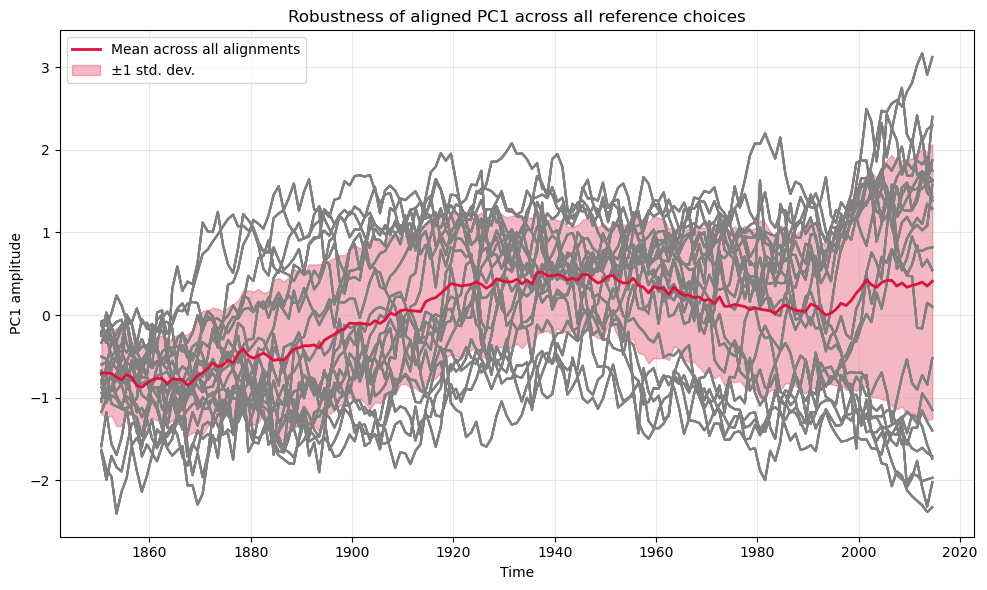

In [12]:
# =====================================================
# Plot 3: Ensemble spread of PC1 across all alignments
# =====================================================

all_pc1 = []  # to collect every PC1 time series from all alignments

for i_ref, ref_member in enumerate(members):
    ref_pc1_list = []
    for i_target, target_member in enumerate(members):
        pc1 = pcs_dict[target_member][:, 0]  # PC1 from this member
        ref_pc1_list.append(pc1)
        all_pc1.append(pc1)
    
    # Combine PC1s for this reference
    ref_pc1 = xr.concat(ref_pc1_list, dim="member")
    ref_pc1["member"] = members
    ref_pc1_mean = ref_pc1.mean(dim="member")
    
# Combine all runs (24×24)
all_pc1 = xr.concat(all_pc1, dim="combo")

# Compute mean and spread across all alignments
pc1_mean = all_pc1.mean(dim="combo")
pc1_std  = all_pc1.std(dim="combo")

# Plot
fig, ax = plt.subplots(figsize=(10,6))

# Spaghetti: all alignments (light gray)
for i in range(all_pc1.sizes["combo"]):
    ax.plot(all_pc1["time"], all_pc1.isel(combo=i), color="gray", alpha=0.2)

# Ensemble mean ± std shading
ax.plot(pc1_mean["time"], pc1_mean, color="crimson", lw=2, label="Mean across all alignments")
ax.fill_between(pc1_mean["time"], pc1_mean - pc1_std, pc1_mean + pc1_std,
                color="crimson", alpha=0.3, label="±1 std. dev.")

ax.set_xlabel("Time")
ax.set_ylabel("PC1 amplitude")
ax.set_title("Robustness of aligned PC1 across all reference choices")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


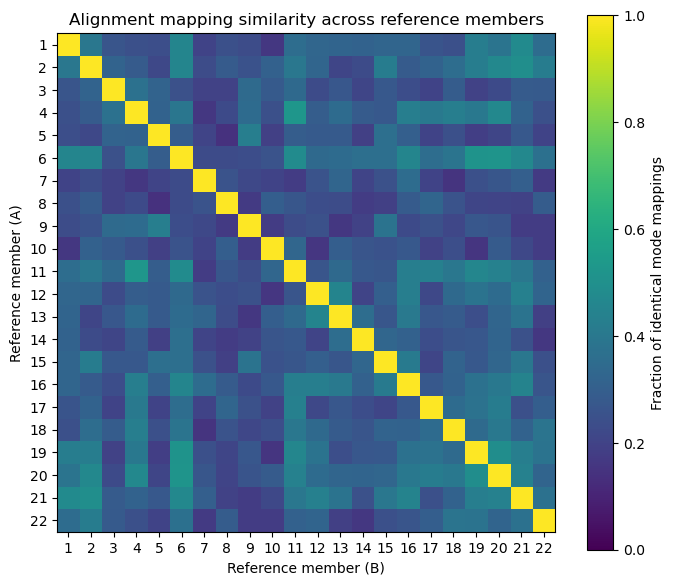

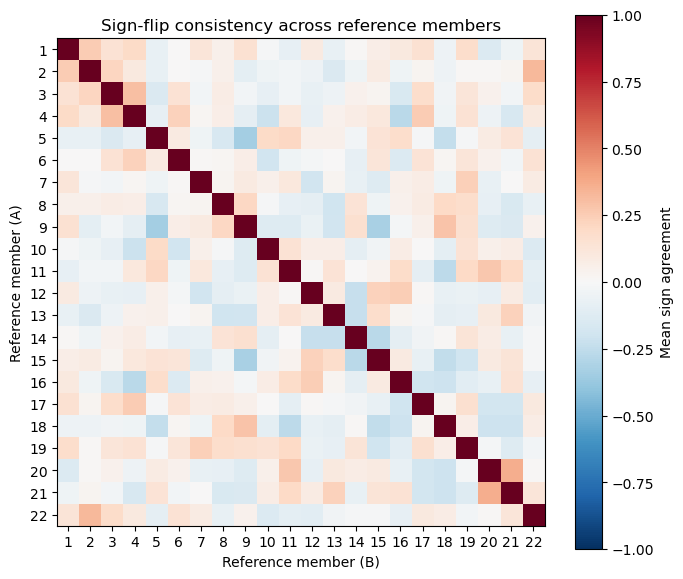

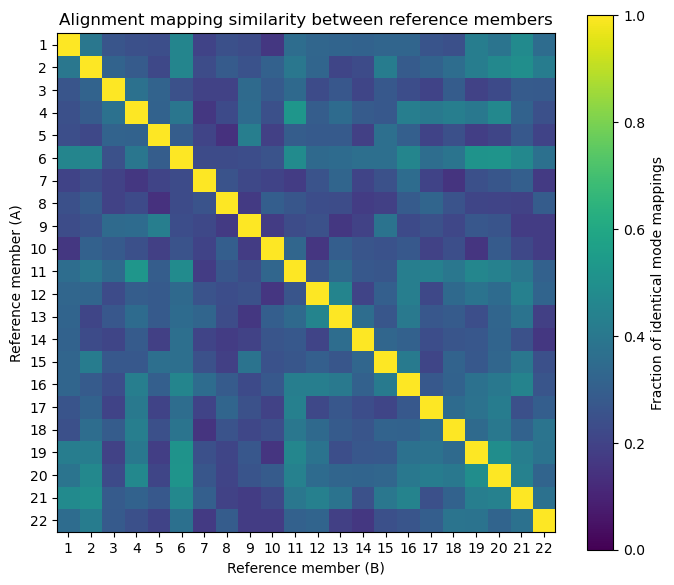

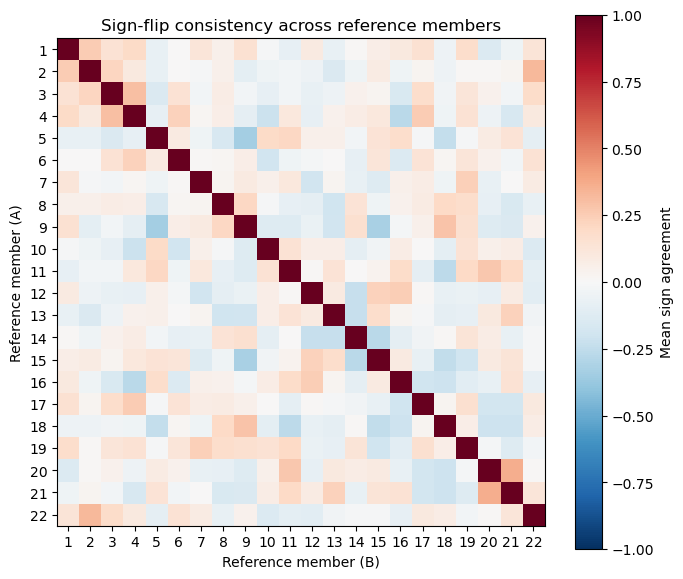

In [14]:
# =====================================================
# Compare how alignment changes with reference choice
# =====================================================
n_ref = len(members)
n_modes = eofs_dict[members[0]].sizes["mode"]

mapping_similarity = np.zeros((n_ref, n_ref))
sign_similarity = np.zeros((n_ref, n_ref))

for i in range(n_ref):
    for j in range(n_ref):
        sims = []
        sign_sims = []
        for t in range(n_ref):  # loop over target members
            # Compare the mapping patterns for the same target under two different references
            same_map = (mapping_all[i, t, :] == mapping_all[j, t, :])
            sims.append(same_map.mean())
            
            # Compare the sign flip patterns for same target
            same_sign = np.nanmean(sign_all[i, t, :] * sign_all[j, t, :])
            sign_sims.append(same_sign)
        
        mapping_similarity[i, j] = np.mean(sims)
        sign_similarity[i, j] = np.mean(sign_sims)

# =====================================================
# Plot: Mapping similarity heatmap
# =====================================================
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(mapping_similarity, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Fraction of identical mode mappings")
ax.set_title("Alignment mapping similarity across reference members")
ax.set_xlabel("Reference member (B)")
ax.set_ylabel("Reference member (A)")
ax.set_xticks(range(n_ref))
ax.set_yticks(range(n_ref))
ax.set_xticklabels(range(1, n_ref+1))
ax.set_yticklabels(range(1, n_ref+1))
plt.tight_layout()
plt.show()

# =====================================================
# Plot: Sign similarity heatmap
# =====================================================
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(sign_similarity, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Mean sign agreement")
ax.set_title("Sign-flip consistency across reference members")
ax.set_xlabel("Reference member (B)")
ax.set_ylabel("Reference member (A)")
ax.set_xticks(range(n_ref))
ax.set_yticks(range(n_ref))
ax.set_xticklabels(range(1, n_ref+1))
ax.set_yticklabels(range(1, n_ref+1))
plt.tight_layout()
plt.show()


# =====================================================
# Plot: Mapping similarity heatmap
# =====================================================
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(mapping_similarity, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Fraction of identical mode mappings")
ax.set_title("Alignment mapping similarity between reference members")
ax.set_xlabel("Reference member (B)")
ax.set_ylabel("Reference member (A)")
ax.set_xticks(range(n_ref))
ax.set_yticks(range(n_ref))
ax.set_xticklabels(range(1, n_ref+1))
ax.set_yticklabels(range(1, n_ref+1))
plt.tight_layout()
plt.show()

# =====================================================
# Plot: Sign similarity heatmap
# =====================================================
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(sign_similarity, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Mean sign agreement")
ax.set_title("Sign-flip consistency across reference members")
ax.set_xlabel("Reference member (B)")
ax.set_ylabel("Reference member (A)")
ax.set_xticks(range(n_ref))
ax.set_yticks(range(n_ref))
ax.set_xticklabels(range(1, n_ref+1))
ax.set_yticklabels(range(1, n_ref+1))
plt.tight_layout()
plt.show()


Aligning for each reference: 100%|██████████| 22/22 [00:53<00:00,  2.44s/it]


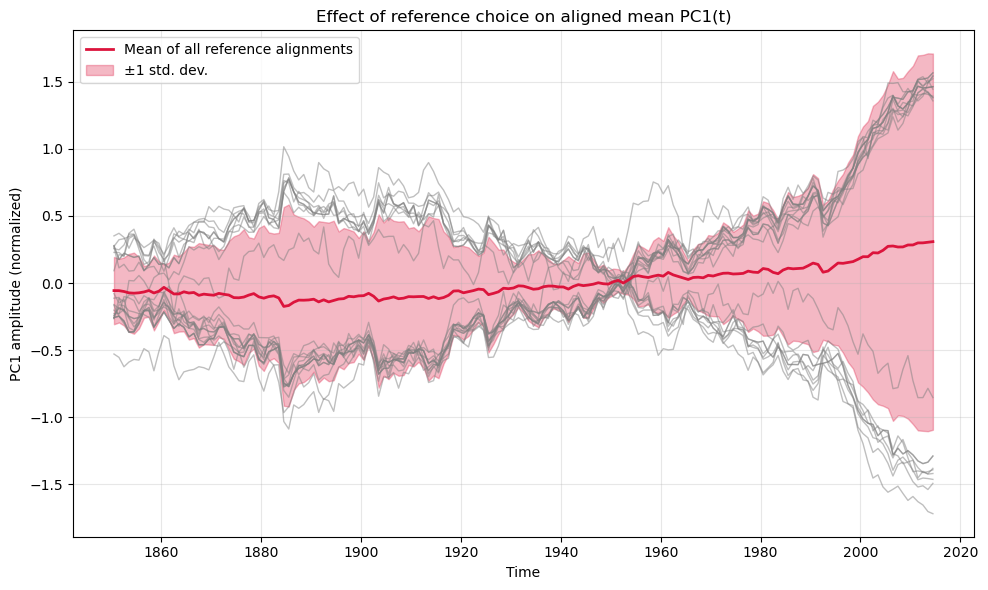

In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# =====================================================
# Compute mean PC1 for each reference alignment
# =====================================================

n_ref = len(members)
n_modes = eofs_dict[members[0]].sizes["mode"]

pc1_means = []

for i_ref, ref_member in enumerate(tqdm(members, desc="Aligning for each reference")):
    ref_eofs = eofs_dict[ref_member]
    
    aligned_pc1s = []
    for target_member in members:
        eofs = eofs_dict[target_member]
        pcs = pcs_dict[target_member]
        
        # Compute correlation matrix between ref and target EOFs
        corr_matrix = np.zeros((n_modes, n_modes))
        for i in range(n_modes):
            for j in range(n_modes):
                corr_matrix[i, j] = pattern_corr(ref_eofs.isel(mode=i), eofs.isel(mode=j))
        
        # Find best matches
        best_match = np.argmax(np.abs(corr_matrix), axis=0)
        reordered_pcs = pcs[:, best_match]
        
        # Flip sign if needed
        for m in range(n_modes):
            if corr_matrix[m, best_match[m]] < 0:
                reordered_pcs[:, m] *= -1
        
        # Store aligned PC1
        aligned_pc1s.append(reordered_pcs[:, 0])
    
    # Mean PC1 across ensemble members (aligned to this reference)
    aligned_pc1s = xr.concat(aligned_pc1s, dim="member")
    aligned_pc1s["member"] = members
    pc1_mean_ref = aligned_pc1s.mean(dim="member")
    pc1_means.append(pc1_mean_ref)

# Stack all reference-based mean PC1s
pc1_means = xr.concat(pc1_means, dim="ref")
pc1_means["ref"] = members

# Compute overall mean and std
pc1_mean_global = pc1_means.mean(dim="ref")
pc1_std_global  = pc1_means.std(dim="ref")

# =====================================================
# Plot: Mean PC1(t) for all reference alignments
# =====================================================
fig, ax = plt.subplots(figsize=(10,6))

# 24 reference-based means (gray)
for i in range(pc1_means.sizes["ref"]):
    ax.plot(pc1_means["time"], pc1_means.isel(ref=i), color="gray", alpha=0.5, lw=1)

# Overall mean ± std
ax.plot(pc1_mean_global["time"], pc1_mean_global, color="crimson", lw=2, label="Mean of all reference alignments")
ax.fill_between(pc1_mean_global["time"], 
                pc1_mean_global - pc1_std_global, 
                pc1_mean_global + pc1_std_global,
                color="crimson", alpha=0.3, label="±1 std. dev.")

ax.set_xlabel("Time")
ax.set_ylabel("PC1 amplitude (normalized)")
ax.set_title("Effect of reference choice on aligned mean PC1(t)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


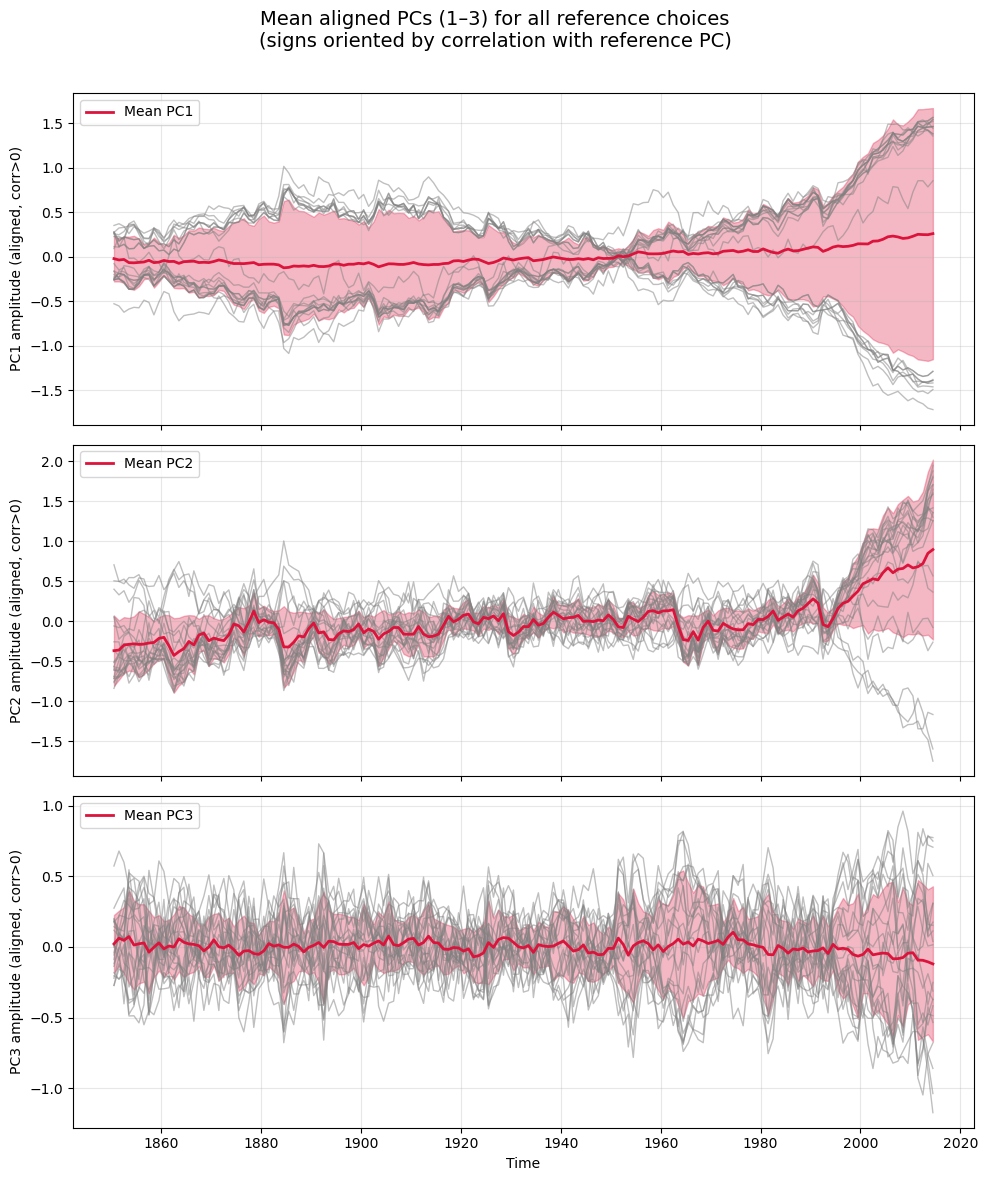

In [20]:
# =====================================================
# Robust sign alignment: flip so each mean PC correlates positively
# with the reference member's original PC
# =====================================================

def enforce_positive_corr(pc_mean_ref, ref_pc):
    """Flip sign so mean PC correlates positively with reference PC."""
    corr = np.corrcoef(pc_mean_ref, ref_pc)[0, 1]
    return -pc_mean_ref if corr < 0 else pc_mean_ref

pc_means_all = []  # store mean PCs for modes 1–3

for mode in [0, 1, 2]:
    pc_means = []
    for i_ref, ref_member in enumerate(members):
        ref_eofs = eofs_dict[ref_member]
        ref_pc_refmember = pcs_dict[ref_member][:, mode]  # reference's own PC for correlation
        aligned_pcs = []

        for target_member in members:
            eofs = eofs_dict[target_member]
            pcs = pcs_dict[target_member]

            # Compute correlation matrix for alignment
            corr_matrix = np.zeros((n_modes, n_modes))
            for i in range(n_modes):
                for j in range(n_modes):
                    corr_matrix[i, j] = pattern_corr(ref_eofs.isel(mode=i), eofs.isel(mode=j))
            
            best_match = np.argmax(np.abs(corr_matrix), axis=0)
            reordered_pcs = pcs[:, best_match]

            for m in range(n_modes):
                if corr_matrix[m, best_match[m]] < 0:
                    reordered_pcs[:, m] *= -1

            aligned_pcs.append(reordered_pcs[:, mode])

        aligned_pcs = xr.concat(aligned_pcs, dim="member")
        aligned_pcs["member"] = members
        pc_mean_ref = aligned_pcs.mean(dim="member")

        # Flip sign if correlation with reference PC is negative
        pc_mean_ref = enforce_positive_corr(pc_mean_ref, ref_pc_refmember)

        pc_means.append(pc_mean_ref)

    # Stack all reference-based means for this mode
    pc_means = xr.concat(pc_means, dim="ref")
    pc_means["ref"] = members
    pc_means_all.append(pc_means)

# =====================================================
# Plot: Mean PCs (1–3) after robust sign alignment
# =====================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for mode, ax in enumerate(axes):
    pc_means = pc_means_all[mode]
    pc_mean_global = pc_means.mean(dim="ref")
    pc_std_global = pc_means.std(dim="ref")

    # gray: each reference-based mean PC
    for i in range(pc_means.sizes["ref"]):
        ax.plot(pc_means["time"], pc_means.isel(ref=i), color="gray", alpha=0.5, lw=1)

    # red: global mean ± std
    ax.plot(pc_mean_global["time"], pc_mean_global, color="crimson", lw=2, label=f"Mean PC{mode+1}")
    ax.fill_between(pc_mean_global["time"],
                    pc_mean_global - pc_std_global,
                    pc_mean_global + pc_std_global,
                    color="crimson", alpha=0.3)
    
    ax.set_ylabel(f"PC{mode+1} amplitude (aligned, corr>0)")
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time")
fig.suptitle("Mean aligned PCs (1–3) for all reference choices\n(signs oriented by correlation with reference PC)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("/data/users/frekle/EOF/EC-Earth3/Figures/thetao/Aligned/Mean_Aligned_PCs.png", dpi=300)
plt.show()



Using r1i1p1f1 as the fixed reference for sign alignment.

Aligning PC1 for all reference choices...

Aligning PC2 for all reference choices...

Aligning PC3 for all reference choices...


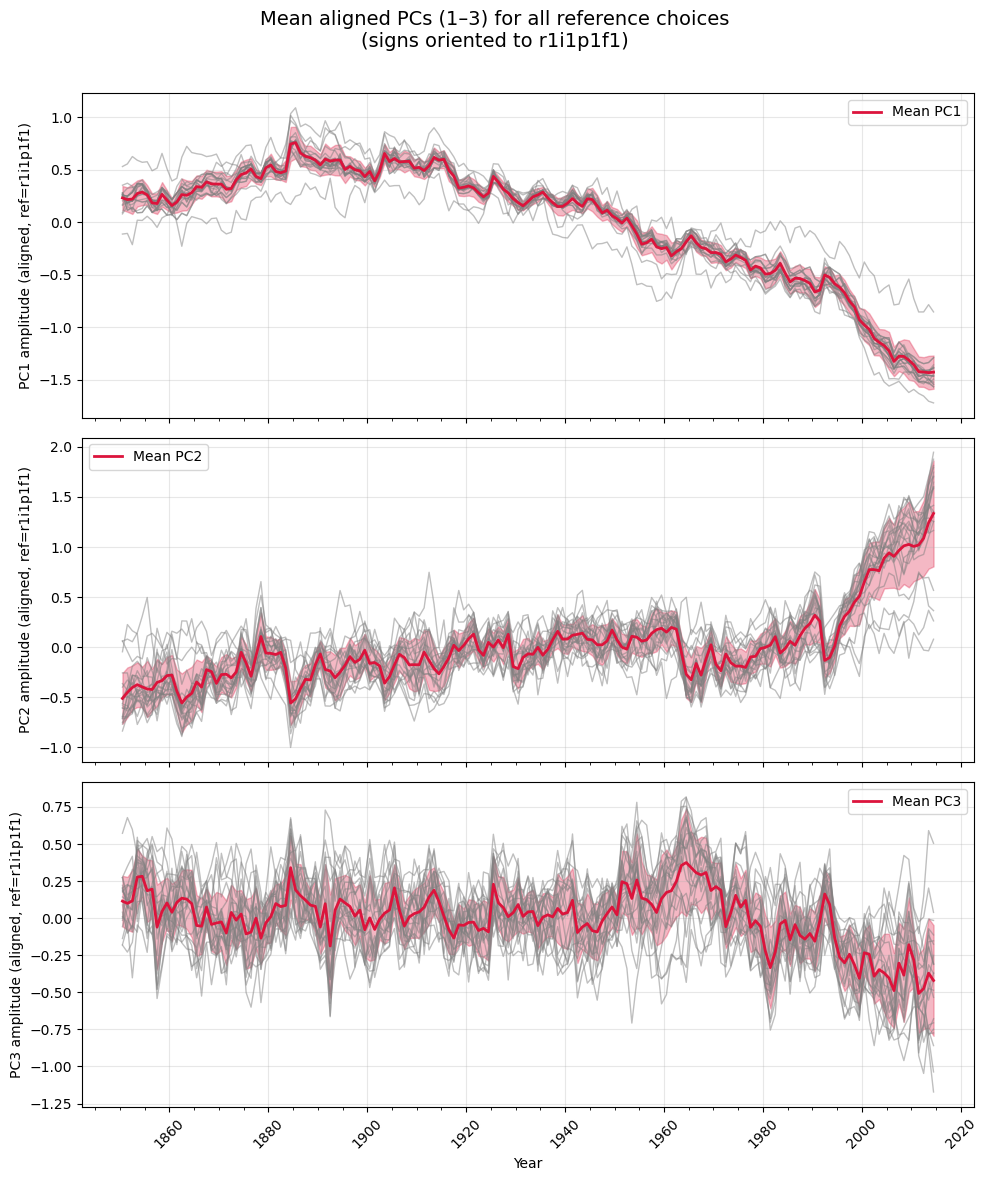

In [17]:
# =====================================================
# Alignment diagnostics with one fixed global reference
# =====================================================

fixed_ref_member = "r1i1p1f1"  # <-- set your chosen reference here
print(f"Using {fixed_ref_member} as the fixed reference for sign alignment.")

def enforce_positive_corr(pc_mean_ref, global_ref_pc):
    """Flip sign if correlation with fixed reference PC is negative."""
    corr = np.corrcoef(pc_mean_ref, global_ref_pc)[0, 1]
    return -pc_mean_ref if corr < 0 else pc_mean_ref

pc_means_all = []  # store mean PCs for modes 1–3

for mode in [0, 1, 2]:
    print(f"\nAligning PC{mode+1} for all reference choices...")
    global_ref_pc = pcs_dict[fixed_ref_member][:, mode]
    pc_means = []

    for i_ref, ref_member in enumerate(members):
        ref_eofs = eofs_dict[ref_member]
        aligned_pcs = []

        for target_member in members:
            eofs = eofs_dict[target_member]
            pcs = pcs_dict[target_member]

            # Compute correlation matrix for alignment
            corr_matrix = np.zeros((n_modes, n_modes))
            for i in range(n_modes):
                for j in range(n_modes):
                    corr_matrix[i, j] = pattern_corr(ref_eofs.isel(mode=i), eofs.isel(mode=j))
            
            best_match = np.argmax(np.abs(corr_matrix), axis=0)
            reordered_pcs = pcs[:, best_match]

            for m in range(n_modes):
                if corr_matrix[m, best_match[m]] < 0:
                    reordered_pcs[:, m] *= -1

            aligned_pcs.append(reordered_pcs[:, mode])

        aligned_pcs = xr.concat(aligned_pcs, dim="member")
        aligned_pcs["member"] = members
        pc_mean_ref = aligned_pcs.mean(dim="member")

        # Flip so that it correlates positively with the fixed global reference PC
        pc_mean_ref = enforce_positive_corr(pc_mean_ref, global_ref_pc)

        pc_means.append(pc_mean_ref)

    # Stack all 24 reference-based means for this mode
    pc_means = xr.concat(pc_means, dim="ref")
    pc_means["ref"] = members
    pc_means_all.append(pc_means)

import matplotlib.dates as mdates

# =====================================================
# Plot: Mean PCs (1–3) for all reference alignments (fixed sign, with year axis)
# =====================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for mode, ax in enumerate(axes):
    pc_means = pc_means_all[mode]
    pc_mean_global = pc_means.mean(dim="ref")
    pc_std_global = pc_means.std(dim="ref")

    # gray: all 24 mean PCs (different reference alignments)
    for i in range(pc_means.sizes["ref"]):
        ax.plot(pc_means["time"], pc_means.isel(ref=i), color="gray", alpha=0.5, lw=1)

    # red: global mean ± std
    ax.plot(pc_mean_global["time"], pc_mean_global, color="crimson", lw=2, label=f"Mean PC{mode+1}")
    ax.fill_between(
        pc_mean_global["time"].values,
        (pc_mean_global - pc_std_global).values,
        (pc_mean_global + pc_std_global).values,
        color="crimson",
        alpha=0.3,
    )

    # --- Formatting
    ax.set_ylabel(f"PC{mode+1} amplitude (aligned, ref={fixed_ref_member})")
    ax.legend()
    ax.grid(alpha=0.3)

    # Format x-axis as years
    ax.xaxis.set_major_locator(mdates.YearLocator(20))     # major ticks every 20 years
    ax.xaxis.set_minor_locator(mdates.YearLocator(5))      # minor ticks every 5 years
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)

axes[-1].set_xlabel("Year")
fig.suptitle(
    f"Mean aligned PCs (1–3) for all reference choices\n(signs oriented to {fixed_ref_member})",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("/data/users/frekle/EOF/EC-Earth3/Figures/thetao/Aligned/Mean_Aligned_PCs_sign_orientated.png", dpi=300)
plt.show()



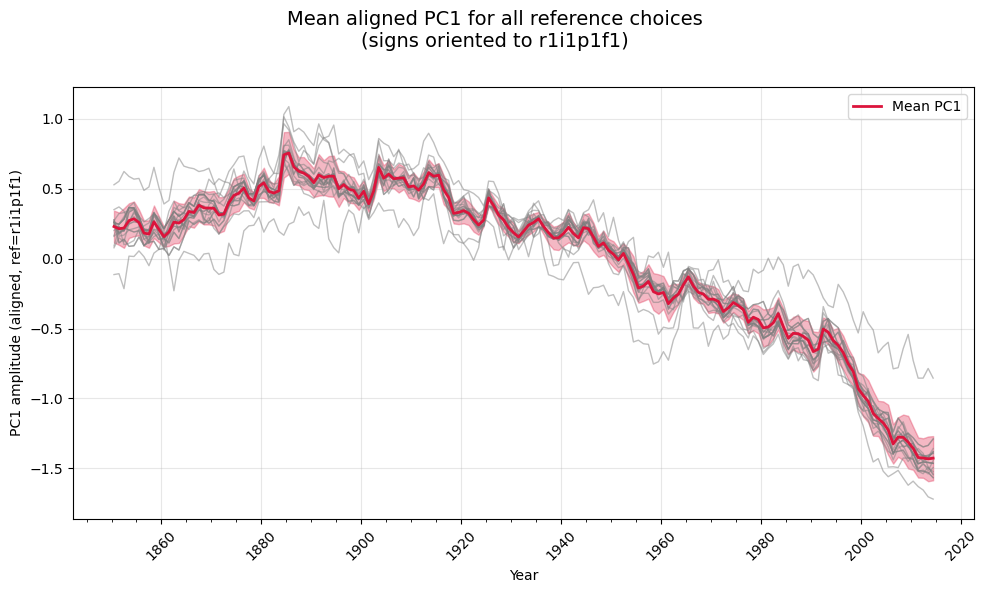

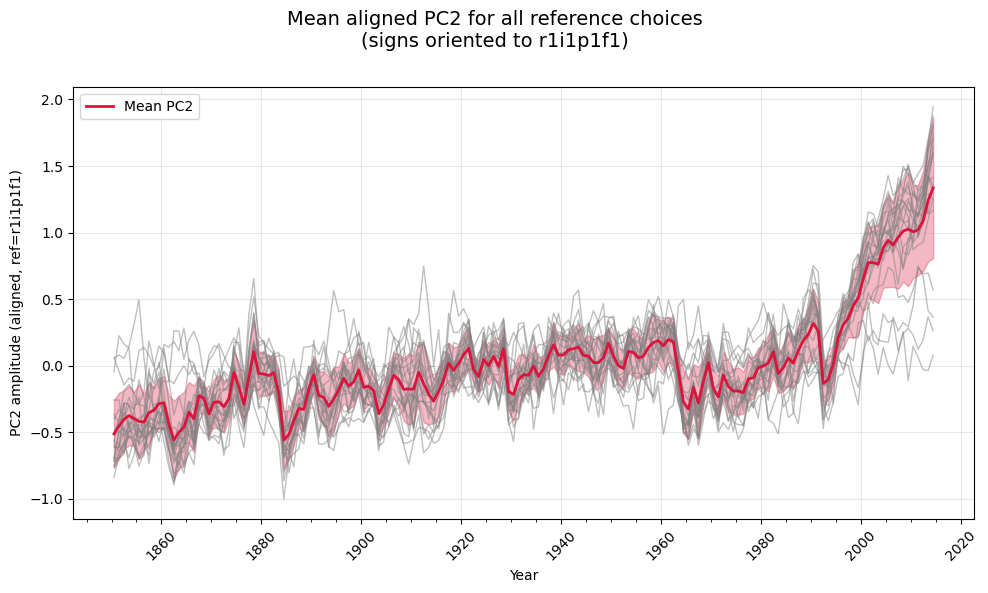

In [19]:
# plot only for PC1
fig, ax = plt.subplots(figsize=(10, 6))
pc_means = pc_means_all[0]  # PC1
pc_mean_global = pc_means.mean(dim="ref")
pc_std_global = pc_means.std(dim="ref")
# gray: all 24 mean PCs (different reference alignments)
for i in range(pc_means.sizes["ref"]):
    ax.plot(pc_means["time"], pc_means.isel(ref=i), color="gray", alpha=0.5, lw=1)
# red: global mean ± std
ax.plot(pc_mean_global["time"], pc_mean_global, color="crimson", lw=2, label=f"Mean PC1")
ax.fill_between(
    pc_mean_global["time"].values,
    (pc_mean_global - pc_std_global).values,
    (pc_mean_global + pc_std_global).values,
    color="crimson",
    alpha=0.3,
)
# --- Formatting
ax.set_ylabel(f"PC1 amplitude (aligned, ref={fixed_ref_member})")
ax.legend()
ax.grid(alpha=0.3)
# Format x-axis as years
ax.xaxis.set_major_locator(mdates.YearLocator(20))     # major ticks every 20 years
ax.xaxis.set_minor_locator(mdates.YearLocator(5))      # minor ticks every 5 years
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)
ax.set_xlabel("Year")
fig.suptitle(
    f"Mean aligned PC1 for all reference choices\n(signs oriented to {fixed_ref_member})",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig("/data/users/frekle/EOF/EC-Earth3/Figures/thetao/Aligned/Mean_Aligned_PC1_sign_orientated.png", dpi=300)
plt.show()

# plot only for PC2
fig, ax = plt.subplots(figsize=(10, 6))
pc_means = pc_means_all[1]  # PC2
pc_mean_global = pc_means.mean(dim="ref")
pc_std_global = pc_means.std(dim="ref")
# gray: all 24 mean PCs (different reference alignments)
for i in range(pc_means.sizes["ref"]):
    ax.plot(pc_means["time"], pc_means.isel(ref=i), color="gray", alpha=0.5, lw=1)
# red: global mean ± std
ax.plot(pc_mean_global["time"], pc_mean_global, color="crimson", lw=2, label=f"Mean PC2")
ax.fill_between(
    pc_mean_global["time"].values,
    (pc_mean_global - pc_std_global).values,
    (pc_mean_global + pc_std_global).values,
    color="crimson",
    alpha=0.3,
)
# --- Formatting
ax.set_ylabel(f"PC2 amplitude (aligned, ref={fixed_ref_member})")
ax.legend()
ax.grid(alpha=0.3)
# Format x-axis as years
ax.xaxis.set_major_locator(mdates.YearLocator(20))     # major ticks every 20 years
ax.xaxis.set_minor_locator(mdates.YearLocator(5))      # minor ticks every 5 years
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)
ax.set_xlabel("Year")
fig.suptitle(
    f"Mean aligned PC2 for all reference choices\n(signs oriented to {fixed_ref_member})",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig("/data/users/frekle/EOF/EC-Earth3/Figures/thetao/Aligned/Mean_Aligned_PC2_sign_orientated.png", dpi=300)
plt.show()

In [22]:
# ===== SAVE EXACT DATA USED FOR THE PLOT (PC1 only) =====
outdir = "/data/users/frekle/EOF/EC-Earth3/Figures/thetao/Aligned"
os.makedirs(outdir, exist_ok=True)

# Use the variables from the plot cell to avoid mismatches
pc1_all_refs = pc_means              # shape: (time, ref)  — gray lines
pc1_mean     = pc_mean_global        # shape: (time,)      — red line
pc1_std      = pc_std_global         # shape: (time,)      — red shading

# Make a tidy Dataset
ds_out = xr.Dataset(
    data_vars=dict(
        pc1_mean_per_ref = (pc1_all_refs.dims, pc1_all_refs.data),   # (time, ref)
        pc1_global_mean  = (pc1_mean.dims,     pc1_mean.data),       # (time,)
        pc1_global_std   = (pc1_std.dims,      pc1_std.data),        # (time,)
    ),
    coords=dict(
        time = pc1_all_refs["time"],
        ref  = pc1_all_refs["ref"],
    ),
    attrs=dict(
        model = "EC-Earth3",
        variable = "thetao",
        note = f"Signs oriented to {fixed_ref_member}, PC1 only; dataset contains exactly what is plotted.",
    ),
)

save_path = f"{outdir}/ECearth3_PC1_plotdata.nc"
ds_out.to_netcdf(save_path)
print(f"✅ Saved plot data → {save_path}")
print(ds_out)


✅ Saved plot data → /data/users/frekle/EOF/EC-Earth3/Figures/thetao/Aligned/ECearth3_PC1_plotdata.nc
<xarray.Dataset> Size: 18kB
Dimensions:           (ref: 22, time: 165)
Coordinates:
  * time              (time) datetime64[ns] 1kB 1850-07-01T06:00:00 ... 2014-...
    mode              int64 8B 0
  * ref               (ref) <U9 792B 'r10i1p1f1' 'r11i1p1f1' ... 'r9i1p1f1'
Data variables:
    pc1_mean_per_ref  (ref, time) float32 15kB 0.1604 0.1908 ... -1.529 -1.567
    pc1_global_mean   (time) float32 660B 0.2304 0.2148 0.2199 ... -1.432 -1.427
    pc1_global_std    (time) float32 660B 0.1143 0.1156 0.1419 ... 0.1601 0.1582
Attributes:
    model:     EC-Earth3
    variable:  thetao
    note:      Signs oriented to r1i1p1f1, PC1 only; dataset contains exactly...


### Remove mean trend

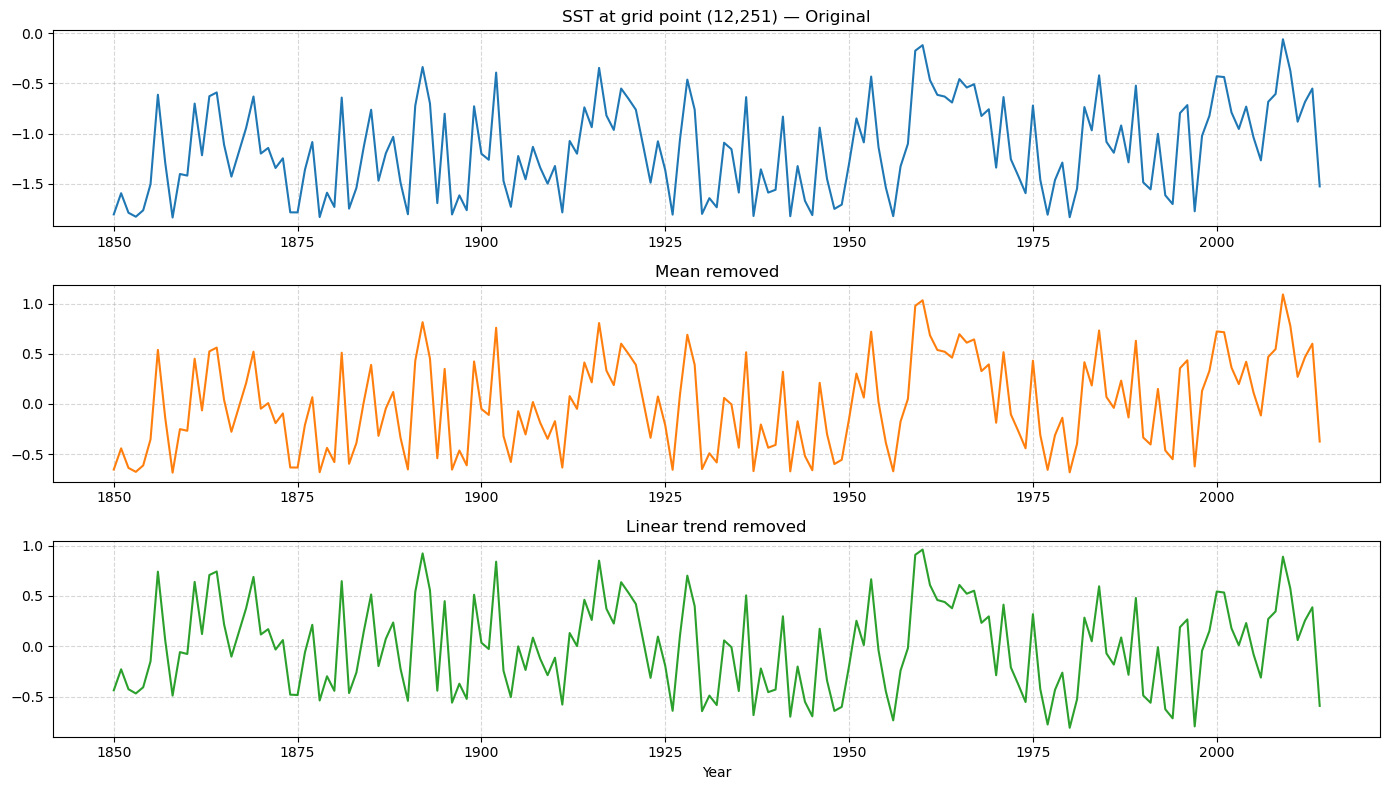

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Helper: detrend full field
# -----------------------------
def detrend_field(da, deg=1):
    """
    Remove a polynomial (default linear) trend from every grid cell.
    Uses xarray.polyfit → handles NaNs automatically.
    """
    fit = da.polyfit(dim="time", deg=deg)
    trend = xr.polyval(da["time"], fit.polyfit_coefficients)
    return da - trend


# -----------------------------
# 1. Load SST data (surface only)
# -----------------------------
member = "r1i1p1f1"
var = "thetao"

data_path = f"/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/{var}/{var}_masked_{member}.nc"

ds = xr.open_dataset(data_path)
da = ds[var]

# Extract surface layer
if "lev" in da.dims:
    da = da.isel(lev=0)

# Make sure time matches your EOF analysis
da = da.sel(time=slice("1840", "2014"))

# Attach coordinates correctly
if "latitude" in ds and "longitude" in ds:
    da = da.assign_coords(lat=ds["latitude"], lon=ds["longitude"])


# -----------------------------
# 2. Preprocess versions
# -----------------------------
da_mean_removed = da - da.mean("time")
da_detrended = detrend_field(da, deg=1)   # linear trend


# -----------------------------
# 3. Pick a valid ocean grid cell
# -----------------------------
valid_mask = np.isfinite(da.mean("time"))
j0, i0 = np.argwhere(valid_mask.values)[200]   # choose a safe ocean point

ts_orig = da[:, j0, i0]
ts_mean = da_mean_removed[:, j0, i0]
ts_detr = da_detrended[:, j0, i0]

years = da["time"].dt.year     # convert time to years


# -----------------------------
# 4. Plot
# -----------------------------
plt.figure(figsize=(14,8))

plt.subplot(3,1,1)
plt.plot(years, ts_orig)
plt.title(f"SST at grid point ({j0},{i0}) — Original")
plt.grid(True, ls="--", alpha=0.5)

plt.subplot(3,1,2)
plt.plot(years, ts_mean, color="tab:orange")
plt.title("Mean removed")
plt.grid(True, ls="--", alpha=0.5)

plt.subplot(3,1,3)
plt.plot(years, ts_detr, color="tab:green")
plt.title("Linear trend removed")
plt.xlabel("Year")
plt.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()



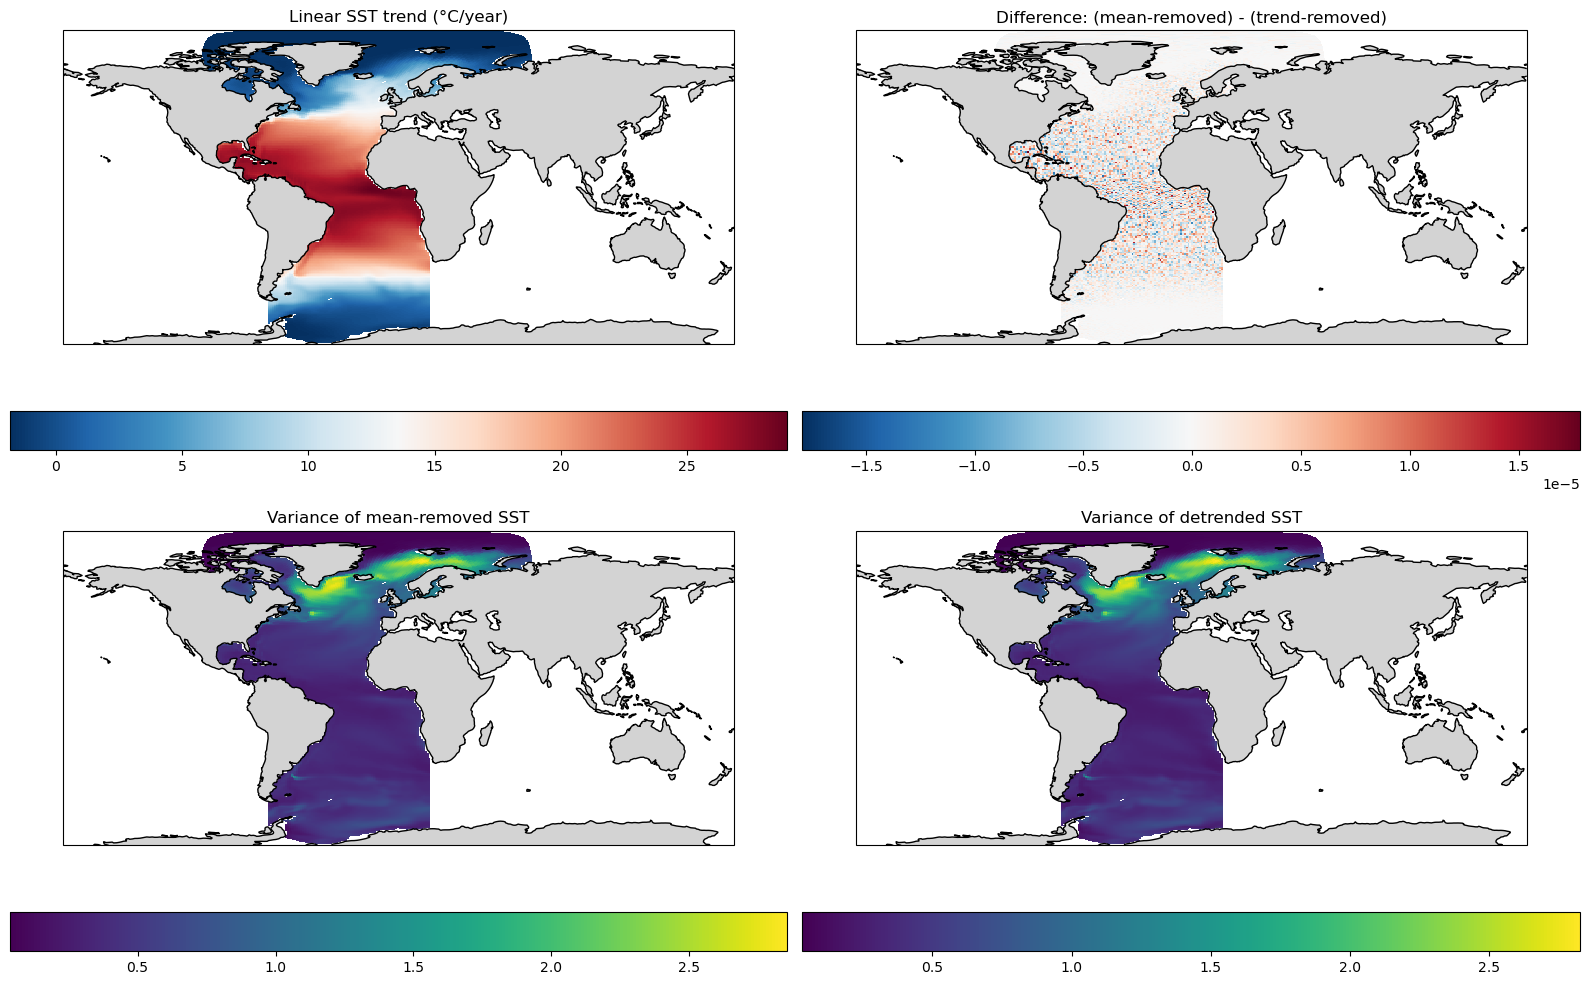

In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def detrend_field(da, deg=1):
    fit = da.polyfit(dim="time", deg=deg)
    trend = xr.polyval(da["time"], fit.polyfit_coefficients)
    return da - trend, trend

# -----------------------------
# Load surface SST
# -----------------------------
member = "r1i1p1f1"
var = "thetao"

ds = xr.open_dataset(f"/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/{var}/{var}_masked_{member}.nc")
da = ds[var]

if "lev" in da.dims:
    da = da.isel(lev=0)

da = da.sel(time=slice("1840", "2014"))
da = da.assign_coords(lat=ds["latitude"], lon=ds["longitude"])

# -----------------------------
# Compute mean-removed and trend-removed
# -----------------------------
da_mean_removed = da - da.mean("time")
da_detrended, trend = detrend_field(da, deg=1)

# -----------------------------
# Plot maps
# -----------------------------
fig = plt.figure(figsize=(16,10))

# 1) Linear trend (slope map)
ax1 = fig.add_subplot(2,2,1, projection=ccrs.PlateCarree())
ax1.set_title("Linear SST trend (°C/year)")
pcm1 = ax1.pcolormesh(da.lon, da.lat, trend.mean("time"), cmap="RdBu_r", shading="auto")
ax1.coastlines(); ax1.add_feature(cfeature.LAND, facecolor="lightgray")
plt.colorbar(pcm1, ax=ax1, orientation="horizontal")

# 2) Difference: mean-removed minus trend-removed
ax2 = fig.add_subplot(2,2,2, projection=ccrs.PlateCarree())
ax2.set_title("Difference: (mean-removed) - (trend-removed)")
diff = da_mean_removed - da_detrended
pcm2 = ax2.pcolormesh(da.lon, da.lat, diff.mean("time"), cmap="RdBu_r", shading="auto")
ax2.coastlines(); ax2.add_feature(cfeature.LAND, facecolor="lightgray")
plt.colorbar(pcm2, ax=ax2, orientation="horizontal")

# 3) Mean-removed anomalies standard deviation
ax3 = fig.add_subplot(2,2,3, projection=ccrs.PlateCarree())
ax3.set_title("Variance of mean-removed SST")
pcm3 = ax3.pcolormesh(da.lon, da.lat, da_mean_removed.std("time"), cmap="viridis", shading="auto")
ax3.coastlines(); ax3.add_feature(cfeature.LAND, facecolor="lightgray")
plt.colorbar(pcm3, ax=ax3, orientation="horizontal")

# 4) Variance of detrended SST
ax4 = fig.add_subplot(2,2,4, projection=ccrs.PlateCarree())
ax4.set_title("Variance of detrended SST")
pcm4 = ax4.pcolormesh(da.lon, da.lat, da_detrended.std("time"), cmap="viridis", shading="auto")
ax4.coastlines(); ax4.add_feature(cfeature.LAND, facecolor="lightgray")
plt.colorbar(pcm4, ax=ax4, orientation="horizontal")

plt.tight_layout()
plt.show()


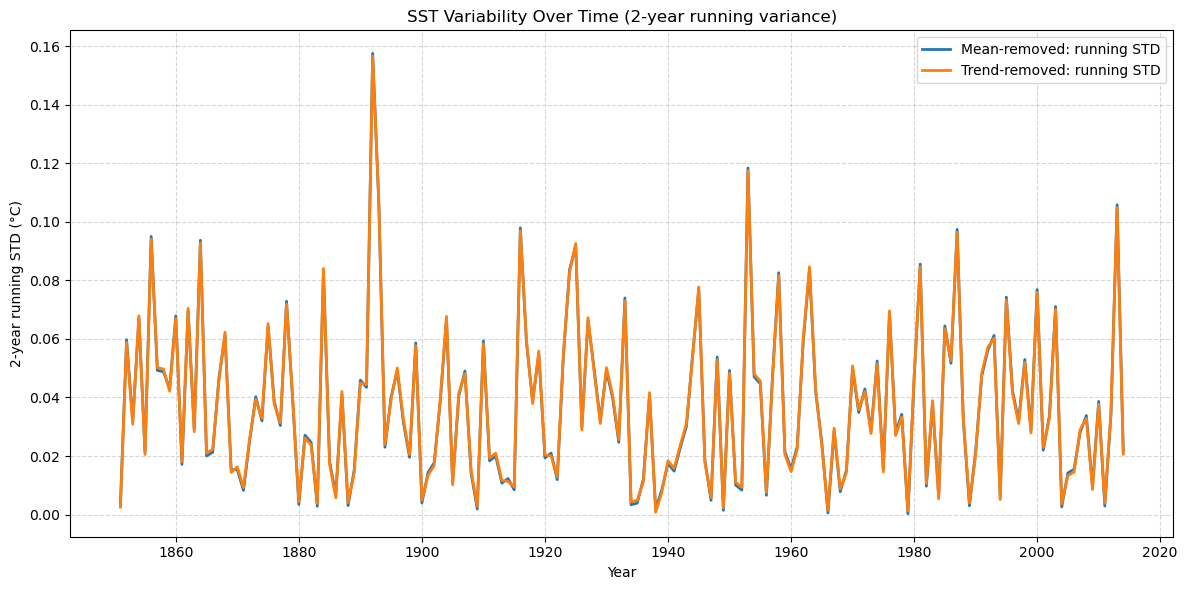

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

def detrend_field(da, deg=1):
    fit = da.polyfit(dim="time", deg=deg)
    trend = xr.polyval(da["time"], fit.polyfit_coefficients)
    return da - trend

# -----------------------------
# Load SST (surface layer)
# -----------------------------
member = "r1i1p1f1"
var = "thetao"
path = f"/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/{var}/{var}_masked_{member}.nc"

ds = xr.open_dataset(path)
da = ds[var]

if "lev" in da.dims:
    da = da.isel(lev=0)

da = da.sel(time=slice("1840", "2014"))
da = da.assign_coords(lat=ds["latitude"], lon=ds["longitude"])

# -----------------------------
# Preprocess
# -----------------------------
da_mean_removed = da - da.mean("time")
da_detrended = detrend_field(da, deg=1)

# -----------------------------
# Domain mean anomalies
# -----------------------------
ts_mean_removed = da_mean_removed.mean(dim=("j", "i"))
ts_detrended     = da_detrended.mean(dim=("j", "i"))

# -----------------------------
# Running (moving window) standard deviation
# -----------------------------
window = 2  # years

var_mean_removed = ts_mean_removed.rolling(time=window, center=True).std()
var_detrended    = ts_detrended.rolling(time=window, center=True).std()

years = da["time"].dt.year

# -----------------------------
# Plot variability over time
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(years, var_mean_removed, label="Mean-removed: running STD", lw=2)
plt.plot(years, var_detrended, label="Trend-removed: running STD", lw=2)

plt.xlabel("Year")
plt.ylabel(f"{window}-year running STD (°C)")
plt.title(f"SST Variability Over Time ({window}-year running variance)")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


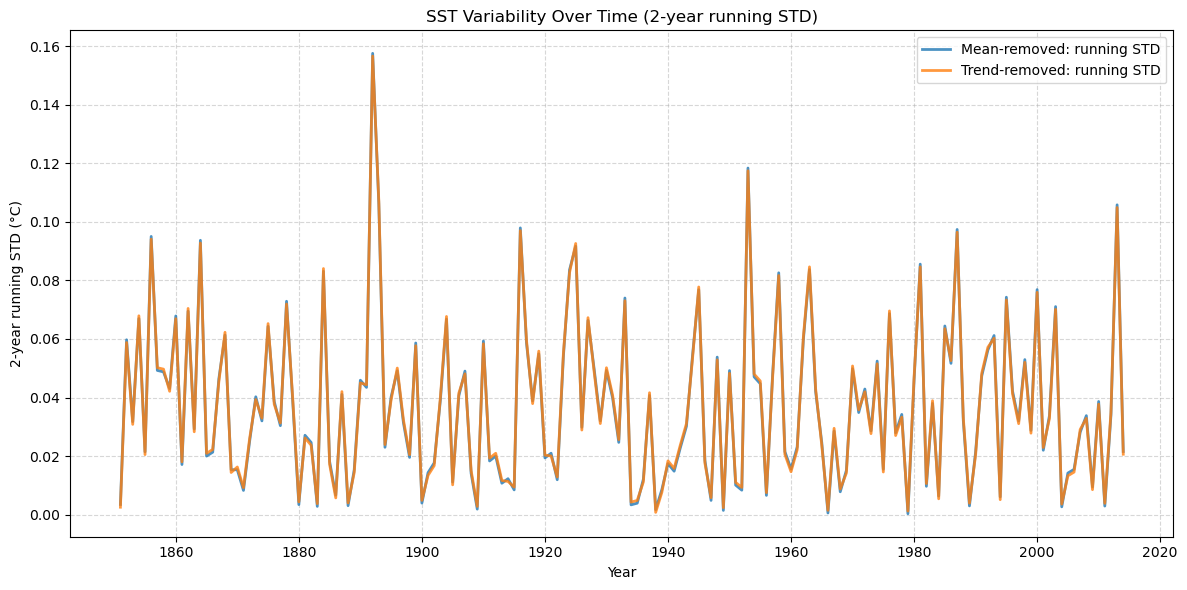

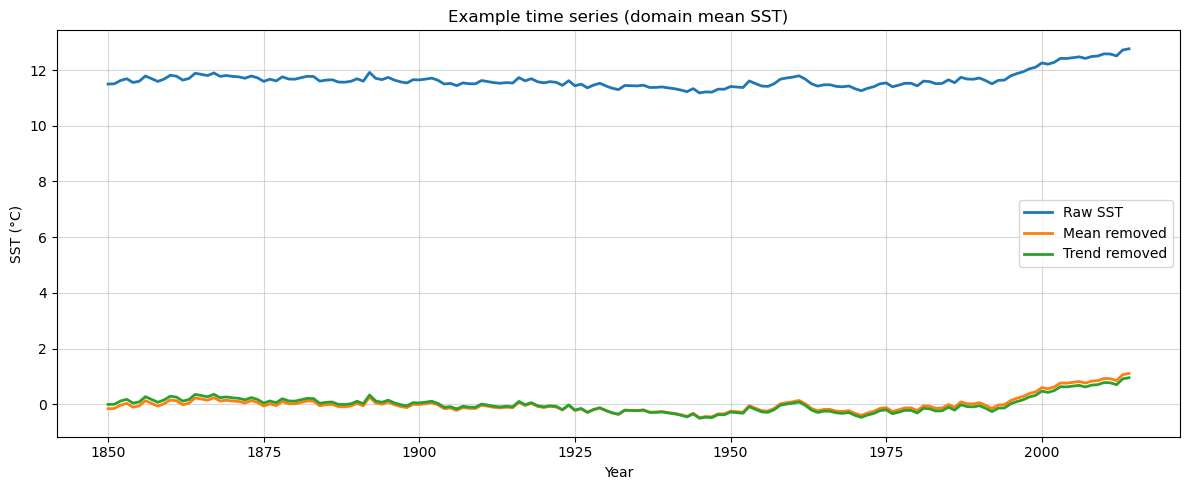

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

def detrend_field(da, deg=1):
    fit = da.polyfit(dim="time", deg=deg)
    trend = xr.polyval(da["time"], fit.polyfit_coefficients)
    return da - trend, trend

# -----------------------------
# Load SST (surface layer)
# -----------------------------
member = "r1i1p1f1"
var = "thetao"
path = f"/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/{var}/{var}_masked_{member}.nc"

ds = xr.open_dataset(path)
da = ds[var]

if "lev" in da.dims:
    da = da.isel(lev=0)

da = da.sel(time=slice("1840", "2014"))
da = da.assign_coords(lat=ds["latitude"], lon=ds["longitude"])

# -----------------------------
# Preprocess
# -----------------------------
da_mean_removed = da - da.mean("time")

da_detrended, trend = detrend_field(da, deg=1)

# -----------------------------
# Domain mean anomalies
# -----------------------------
ts_raw          = da.mean(dim=("j", "i"))              # No mean removal, no detrend
ts_mean_removed = da_mean_removed.mean(dim=("j", "i"))
ts_detrended    = da_detrended.mean(dim=("j", "i"))

# -----------------------------
# Running (moving window) standard deviation
# -----------------------------
window = 2  # years (use 10 so it matches din supervisor kommentar)

var_raw          = ts_raw.rolling(time=window, center=True).std()
var_mean_removed = ts_mean_removed.rolling(time=window, center=True).std()
var_detrended    = ts_detrended.rolling(time=window, center=True).std()

years = da["time"].dt.year

# -----------------------------
# Plot variability over time
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(years, var_mean_removed, label="Mean-removed: running STD",     lw=2, alpha=0.8)
plt.plot(years, var_detrended,    label="Trend-removed: running STD",    lw=2, alpha=0.8)

plt.xlabel("Year")
plt.ylabel(f"{window}-year running STD (°C)")
plt.title(f"SST Variability Over Time ({window}-year running STD)")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# EXTRA: Plot one example time series before/after detrending
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(years, ts_raw,          label="Raw SST", lw=2)
plt.plot(years, ts_mean_removed, label="Mean removed", lw=2)
plt.plot(years, ts_detrended,    label="Trend removed", lw=2)

plt.xlabel("Year")
plt.ylabel("SST (°C)")
plt.title("Example time series (domain mean SST)")
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()
